In [156]:
%matplotlib ipympl

In [157]:
# ======================================================================
# DIELECTRIC LOSS INPUTS (STARTING VALUES TO SWEEP)
# ======================================================================

# Recommended starting points:
#   tan_delta_Si ~ 5e-6 for good crystalline Si at mK
#   tan_delta_JJ and tan_delta_SQUID are much less certain -> sweep them
tan_delta_Si = 5e-6
tan_delta_JJ = 1e-6
tan_delta_SQUID = 1e-6

In [158]:
import numpy as np
import scipy.constants as const

import scqubits as scq
hbar = const.hbar


# 1. Define physical constants and conversion factors
h = const.h                      # Planck constant in J*s
e = const.e                      # Elementary charge in C
Phi0 = h / (2 * e)               # Magnetic flux quantum in Wb
GHz = 1e9                        # Conversion for Hz to GHz
fF_to_F = 1e-15                  # femtoFarad to Farad

# 2. Define input parameters
fp_target_GHz = 50          # Target plasma frequency in GHz: 50 GHz (0.14 Torr) to 55 GHz (0.07 Torr)
wp_target = 2 * np.pi * fp_target_GHz * GHz # Target angular frequency in rad/s

# Junction dimensions
W_um = 0.260                       # Width in um (260 nm)
L_um = 1                         # Length in um 2.8 is the largest
N = 51              # number of cells
# for N in [120]:

C_area_fF_per_um2 = 45.0         # Capacitance per unit area in fF/um^2 (Assumed)

# 3. Calculate Junction Capacitance (C_J)
Area_um2 = W_um * L_um
CJ = C_area_fF_per_um2 * Area_um2 * fF_to_F # Junction capacitance C in Farads (F)

# 4. Calculate Josephson Inductance (L_J)
# Formula: wp = 1/sqrt(LJ * CJ) => LJ = 1 / (wp^2 * CJ)
LJ = 1.0 / (wp_target**2 * CJ)  # Josephson Inductance L in Henries (H)

# 5. Calculate Josephson Energy (E_J)
# Formula: EJ = (Phi0 / (2*pi))^2 / LJ
EJ = (Phi0 / (2 * np.pi))**2 / LJ # Josephson Energy EJ in Joules (J)
EJ_GHz = EJ / h  / GHz              # Josephson Energy EJ in GHz

# 6. Calculate Charging Energy (E_C)
# Formula: EC = e^2 / (2 * (2 * CJ))
EC = e**2 / (2 * CJ)             # Charging Energy EC in Joules (J)
EC_GHz = EC / h  / GHz                  # Charging Energy EC in GHz


# Cg_over_CJ = 0.10       # stray-to-ground ratio
Cg = 4.5e-18 ###Cg_over_CJ * CJ

# --- Chain design targets (edit here) ---
a = W_um * 1e-6                # cell pitch [m] (for bookkeeping; not critical here)


#########################################
R = 50.0                       # target wave impedance [Ohm]
########################################


# Qubit junction dimensions
W_um = 0.260                       # Width in um (260 nm)
L_um = 2.8                        # Length in um
d_length = 0.05

L1_um = L_um*(1-d_length)
L2_um = L_um*(1+d_length)

Area_um2 = W_um * L_um
# CJ_qubit = C_area_fF_per_um2 * Area_um2 * fF_to_F # Junction capacitance C in Farads (F)

CJ1 = C_area_fF_per_um2 * W_um * L1_um * fF_to_F
CJ2 = C_area_fF_per_um2 * W_um * L2_um * fF_to_F

LJ1 = 1.0 / (wp_target**2 * CJ1)  # Josephson Inductance L in Henries (H)
LJ2 = 1.0 / (wp_target**2 * CJ2)  # Josephson Inductance L in Henries (H)

# LJ_qubit = 1.0 / (wp_target**2 * CJ_qubit)  # Josephson Inductance L in Henries (H)

EJ1 = (Phi0 / (2 * np.pi))**2 / LJ1 # Josephson Energy EJ in Joules (J) 
EJ1_GHz = EJ1 / h  / GHz              # Josephson Energy EJ in GHz

EJ2 = (Phi0 / (2 * np.pi))**2 / LJ2 # Josephson Energy EJ in Joules (J) 
EJ2_GHz = EJ2 / h  / GHz              # Josephson Energy EJ in GHz

# EJ_qubit = 2*(Phi0 / (2 * np.pi))**2 / LJ_qubit # Josephson Energy EJ in Joules (J) # factor of 2 for the SQUID
# EJ_qubit_GHz = EJ_qubit / h  / GHz              # Josephson Energy EJ in GHz

EJ_qubit_GHz = (EJ1_GHz + EJ2_GHz) # total EJ of the SQUID is the sum of the two junctions

EC1 = e**2 / (2 * CJ1)             # Charging Energy EC in Joules (J) 
EC1_GHz = EC1 / h  / GHz                  # Charging Energy EC in GHz
EC2 = e**2 / (2 * CJ2)             # Charging Energy EC in Joules (J)
EC2_GHz = EC2 / h  / GHz                  # Charging Energy EC in GHz

EC_qubit = e**2 / (2 * (CJ1 + CJ2))             # Charging Energy EC in Joules (J)
EC_qubit_GHz = EC_qubit / h  / GHz                  # Charging Energy EC in GHz

# EC_qubit = e**2 / (2 * CJ_qubit * 2)             # Charging Energy EC in Joules (J) # factor of 2 for the SQUID since the two junctions are in parallel, so total C is 2*CJ_qubit
# EC_qubit_GHz = EC_qubit / h  / GHz                  # Charging Energy EC in GHz


d = (EJ2 - EJ1)/(EJ2 + EJ1)

Phi_ext = 0.5*Phi0


Cc = 0.16e-15 #0.1e-15             # [F]

N_SQUID = 25 #N//2


qubit_params = {
    'EJ_GHz': EJ_qubit_GHz,
    'EC_GHz': EC_qubit_GHz,
    'd': d,
    'ng': 0.0,
    'ncut': 20,
    'truncated_dim': 10,
    'CJ': CJ1 + CJ2, # total capacitance of the SQUID (two junctions in parallel)
}

print("true d = ", d)

true d =  0.050000000000000065


In [159]:
np.sqrt(8*EJ_qubit_GHz*EC_qubit_GHz)

np.float64(49.99999999999999)

In [160]:
L1_um, L2_um

(2.6599999999999997, 2.94)

In [161]:
MODE_IDX = 1
FREQ1, FREQ2, KAPPA, T1_PURCELL, TPHI_CHARGE, G_COUPLING = None, None, None, None, None, None


In [162]:
print("Junction parameters:")
print(f"  C_J = {CJ*1e15:.2f} fF")
print(f"  L_J = {LJ*1e9:.2f} nH")
print(f"  E_J = {EJ_GHz:.2f} GHz")
print(f"  E_C = {EC_GHz:.2f} GHz")
print(f"  E_J/E_C = {EJ_GHz/EC_GHz:.2f}")
print(f"  C_g = {Cg*1e18:.2f} aF")
print()
print("Qubit parameters:")
print(f"  C_J1 = {CJ1*1e15:.2f} fF")
print(f"  C_J2 = {CJ2*1e15:.2f} fF")
print(f"  C_J_avg = {(CJ1+CJ2)/2*1e15:.2f} fF")
print(f"  L_J1 = {LJ1*1e9:.2f} nH")
print(f"  L_J2 = {LJ2*1e9:.2f} nH")
print(f"  L_J_avg = {(LJ1+LJ2)/2*1e9:.2f} nH")
print(f"  E_J = {EJ_qubit_GHz:.2f} GHz")
print(f"  E_C = {EC_qubit_GHz:.2f} GHz")
print(f"  E_J/E_C = {EJ_qubit_GHz/EC_qubit_GHz:.2f}")
print(EJ1_GHz, EJ2_GHz)

Junction parameters:
  C_J = 11.70 fF
  L_J = 0.87 nH
  E_J = 188.76 GHz
  E_C = 1.66 GHz
  E_J/E_C = 114.01
  C_g = 4.50 aF

Qubit parameters:
  C_J1 = 31.12 fF
  C_J2 = 34.40 fF
  C_J_avg = 32.76 fF
  L_J1 = 0.33 nH
  L_J2 = 0.29 nH
  L_J_avg = 0.31 nH
  E_J = 1057.03 GHz
  E_C = 0.30 GHz
  E_J/E_C = 3575.43
502.09137109279675 554.9430943657228


In [163]:
EJ_qubit_GHz_half_flux = EJ_qubit_GHz * np.cos(np.pi * Phi_ext / Phi0) * np.sqrt(1 + d**2 * np.tan(np.pi * Phi_ext / Phi0)**2)

print("SQUID EJ at half-flux with an:")
print(f"  asymmetry d = {d:.2f}")
print(f"  E_J_SQUID = {EJ_qubit_GHz_half_flux:.2f} GHz")
print(f"EJ/EC at half-flux with an asymmetry d = {d:.2f}:",
      EJ_qubit_GHz * np.cos(np.pi * Phi_ext / Phi0) * np.sqrt(1 + d**2 * np.tan(np.pi * Phi_ext / Phi0)**2) / EC_qubit_GHz) 

print(f"Freq at half-flux with an asymmetry d = {d:.2f}:",
      np.sqrt(8 * EJ_qubit_GHz * np.cos(np.pi * Phi_ext / Phi0) * np.sqrt(1 + d**2 * np.tan(np.pi * Phi_ext / Phi0)**2) * EC_qubit_GHz) - EC_qubit_GHz)

# EJ1 and EJ2 at Phi_ext = 0.5*Phi0 with an asymmetry d = 0.03
EJ1_half_flux = EJ_qubit_GHz_half_flux * (1-d)/2
EJ2_half_flux = EJ_qubit_GHz_half_flux * (1+d)/2
print(f"EJ1 at half-flux with an asymmetry d = {d:.2f}: {EJ1_half_flux:.2f} GHz")
print(f"EJ2 at half-flux with an asymmetry d = {d:.2f}: {EJ2_half_flux:.2f} GHz")
print(f"Total EJ at half-flux with an asymmetry d = {d:.2f}: {EJ1_half_flux + EJ2_half_flux:.2f} GHz")

LJ1_half_flux = (Phi0 / (2 * np.pi))**2 / (EJ1_half_flux * h * GHz)
LJ2_half_flux = (Phi0 / (2 * np.pi))**2 / (EJ2_half_flux * h * GHz)
print(f"LJ1 at half-flux with an asymmetry d = {d:.2f}: {LJ1_half_flux*1e9:.2f} nH")
print(f"LJ2 at half-flux with an asymmetry d = {d:.2f}: {LJ2_half_flux*1e9:.2f} nH")

print(f"Relative difference in inductances at half-flux with an asymmetry d = {d:.2f}: {(LJ1_half_flux - LJ2_half_flux)/(LJ1_half_flux + LJ2_half_flux):.2f}")
print(f"average LJ at half-flux with an asymmetry d = {d:.2f}: {(LJ1_half_flux + LJ2_half_flux)/2*1e9:.2f} nH")
print(f"average CJ at half-flux with an asymmetry d = {d:.2f}: {(CJ1 + CJ2)/2*1e15:.2f} fF")

SQUID EJ at half-flux with an:
  asymmetry d = 0.05
  E_J_SQUID = 52.85 GHz
EJ/EC at half-flux with an asymmetry d = 0.05: 178.77149778674882
Freq at half-flux with an asymmetry d = 0.05: 10.884701466792924
EJ1 at half-flux with an asymmetry d = 0.05: 25.10 GHz
EJ2 at half-flux with an asymmetry d = 0.05: 27.75 GHz
Total EJ at half-flux with an asymmetry d = 0.05: 52.85 GHz
LJ1 at half-flux with an asymmetry d = 0.05: 6.51 nH
LJ2 at half-flux with an asymmetry d = 0.05: 5.89 nH
Relative difference in inductances at half-flux with an asymmetry d = 0.05: 0.05
average LJ at half-flux with an asymmetry d = 0.05: 6.20 nH
average CJ at half-flux with an asymmetry d = 0.05: 32.76 fF


In [164]:
L_per_sheet = 1e-12 # 1 pH per square, for bookkeeping;

SQUIDLidL = 2
SQUIDLidW = 10

SQUIDJJL = 5
SQUIDJJW = 1

chainW = 2.8
SQUIDislandL = 3 

num_sheets_per_SQUID_half = 0.5*SQUIDLidW/SQUIDLidL + SQUIDJJL/SQUIDJJW + SQUIDislandL/chainW

L_SQUID_half = num_sheets_per_SQUID_half * L_per_sheet

EL_SQUID_half = (Phi0 / (2 * np.pi))**2 / L_SQUID_half
EL_SQUID_half_GHz = EL_SQUID_half / h / GHz

(EJ1_GHz**2 / (4*EL_SQUID_half_GHz) + EJ2_GHz**2 / (4*EL_SQUID_half_GHz)) / abs(EJ1_GHz-EJ2_GHz), EL_SQUID_half_GHz, L_SQUID_half*1e12

(0.13891566890577264, 19070.5098274578, 8.571428571428571)

In [165]:
# d = 0.74 * 1e-2
# EJ1 = 84
# EJ2 = EJ1*(1+d)/(1-d)

# L_pH = 20

# EL = (Phi0 / (2 * np.pi))**2 / (L_pH * 1e-12)
# EL_GHz = EL / h / GHz

# (EJ1**2 / (4*EL_GHz) + EJ2**2 / (4*EL_GHz)) / abs(EJ1-EJ2)

In [166]:
# C_J='32.76fF' chainL='0.68um' chainW='2.8um' condT='30nm' extCouplingL='2um' extCouplingW='20um' fstLidL='1um' fstLidW='10um' JJ_dummy_L='0.05um' L_J='0.86nH' N='30' pitL='0um' pitW='1um' spacingChain='0.16um' spacingCoupling='1um' stripeW='465.212um' subL='1.5mm' subT='525um' subW='1.5mm'

# # N=150, fstLidL1um ->
# Cc_first,Cc_last, Cc_middle, Cg_first, Cg_last, Cg_middle = 1.02e-15, 0.38e-15, 0.020e-15, 0.031e-15, 0.24e-15, 0.012e-15
# # N=150, fstLidL5um ->
# Cc_first,Cc_last, Cc_middle, Cg_first, Cg_last, Cg_middle = 2.30e-15, 0.80e-15, 0.012e-15, 0.081e-15, 0.535e-15, 0.0080e-15
# # N=150, fstLidL9um ->
# Cc_first,Cc_last, Cc_middle, Cg_first, Cg_last, Cg_middle = 3.39e-15, 1.09e-15, 0.011e-15, 0.12e-15, 0.769e-15, 0.0072e-15
# # N=150, fstLidL13um ->
# Cc_first,Cc_last, Cc_middle, Cg_first, Cg_last, Cg_middle = 4.44e-15, 1.34e-15, 0.0106e-15, 0.157e-15, 0.991e-15, 0.00668e-15
# # N=150, fstLidL17um ->
# Cc_first,Cc_last, Cc_middle, Cg_first, Cg_last, Cg_middle = 5.47e-15, 1.55e-15, 0.0098e-15, 0.193e-15, 1.20e-15, 0.0065e-15
# # N=150, fstLidL21um ->
# Cc_first,Cc_last, Cc_middle, Cg_first, Cg_last, Cg_middle = 6.52e-15, 1.75e-15, 0.0094e-15, 0.23e-15, 1.42e-15, 0.0067e-15

# # N=130, fstLidL1um ->
# Cc_first,Cc_last, Cc_middle, Cg_first, Cg_last, Cg_middle = 1.027e-15, 0.401e-15, 0.021e-15, 0.032e-15, 0.23e-15, 0.0124e-15
# # N=130, fstLidL5um ->
# Cc_first,Cc_last, Cc_middle, Cg_first, Cg_last, Cg_middle = 2.29e-15, 0.84e-15, 0.013e-15, 0.081e-15, 0.51e-15, 0.0076e-15
# # N=130, fstLidL9um ->
# Cc_first,Cc_last, Cc_middle, Cg_first, Cg_last, Cg_middle = 3.38e-15, 1.14e-15, 0.011e-15, 0.122e-15, 0.738e-15, 0.0068e-15
# # N=130, fstLidL13um ->
# Cc_first,Cc_last, Cc_middle, Cg_first, Cg_last, Cg_middle = 4.44e-15, 1.40e-15, 0.011e-15, 0.159e-15, 0.953e-15, 0.0063e-15
# # N=130, fstLidL17um ->
# Cc_first,Cc_last, Cc_middle, Cg_first, Cg_last, Cg_middle = 5.47e-15, 1.637e-15, 0.0103e-15, 0.195e-15, 1.164e-15, 0.0062e-15
# # N=130, fstLidL21um ->
# Cc_first,Cc_last, Cc_middle, Cg_first, Cg_last, Cg_middle = 6.53e-15, 1.84e-15, 0.0099e-15, 0.23e-15, 1.37e-15, 0.0063e-15

# # N=110, fstLidL1um ->
# Cc_first,Cc_last, Cc_middle, Cg_first, Cg_last, Cg_middle = 1.02e-15, 0.42e-15, 0.023e-15, 0.032e-15, 0.217e-15, 0.0114e-15
# # N=110, fstLidL5um ->
# Cc_first,Cc_last, Cc_middle, Cg_first, Cg_last, Cg_middle = 2.29e-15, 0.88e-15, 0.014e-15, 0.083e-15, 0.48e-15, 0.0073e-15
# # N=110, fstLidL9um ->
# Cc_first,Cc_last, Cc_middle, Cg_first, Cg_last, Cg_middle = 3.38e-15, 1.21e-15, 0.012e-15, 0.124e-15, 0.70e-15, 0.0065e-15
# # N=110, fstLidL13um ->
# Cc_first,Cc_last, Cc_middle, Cg_first, Cg_last, Cg_middle = 4.44e-15, 1.48e-15, 0.011e-15, 0.160e-15, 0.911e-15, 0.00629e-15
# # N=110, fstLidL17um ->
# Cc_first,Cc_last, Cc_middle, Cg_first, Cg_last, Cg_middle = 5.48e-15, 1.72e-15, 0.011e-15, 0.196e-15, 1.116e-15, 0.0060e-15
# # N=110, fstLidL21um ->
# Cc_first,Cc_last, Cc_middle, Cg_first, Cg_last, Cg_middle = 6.50e-15, 1.94e-15, 0.0109e-15, 0.23e-15, 1.316e-15, 0.0057e-15

# # N=90, fstLidL1um ->
# Cc_first,Cc_last, Cc_middle, Cg_first, Cg_last, Cg_middle = 1.02e-15, 0.45e-15, 0.025e-15, 0.033e-15, 0.20e-15, 0.0106e-15
# # N=90, fstLidL5um ->
# Cc_first,Cc_last, Cc_middle, Cg_first, Cg_last, Cg_middle = 2.29e-15, 0.94e-15, 0.015e-15, 0.085e-15, 0.46e-15, 0.0069e-15
# # N=90, fstLidL9um ->
# Cc_first,Cc_last, Cc_middle, Cg_first, Cg_last, Cg_middle = 3.38e-15, 1.285e-15, 0.013e-15, 0.125e-15, 0.66e-15, 0.0063e-15
# # N=90, fstLidL13um ->
# Cc_first,Cc_last, Cc_middle, Cg_first, Cg_last, Cg_middle = 4.44e-15, 1.575e-15, 0.0124e-15, 0.163e-15, 0.865e-15, 0.0056e-15
# # N=90, fstLidL17um ->
# Cc_first,Cc_last, Cc_middle, Cg_first, Cg_last, Cg_middle = 5.48e-15, 1.82e-15, 0.01199e-15, 0.198e-15, 1.062e-15, 0.0056e-15
# # N=90, fstLidL21um ->
# Cc_first,Cc_last, Cc_middle, Cg_first, Cg_last, Cg_middle = 6.50e-15, 2.05e-15, 0.01137e-15, 0.2326e-15, 1.259e-15, 0.00571e-15
# Cc_first,Cc_last, Cc_middle, Cg_first, Cg_last, Cg_middle = 6.456e-15, 0.075e-15, 0.042e-15, 0.249e-15, 0.04138e-15, 0.0225e-15 # assymetric case for N=90, fstLidL21um

# # N=70, fstLidL1um ->
# Cc_first,Cc_last, Cc_middle, Cg_first, Cg_last, Cg_middle = 1.019e-15, 0.4891e-15, 0.0263e-15, 0.03398e-15, 0.186e-15, 0.00989e-15
# # N=70, fstLidL5um ->
# Cc_first,Cc_last, Cc_middle, Cg_first, Cg_last, Cg_middle = 2.297e-15, 1.014e-15, 0.0164e-15, 0.0862e-15, 0.422e-15, 0.0035e-15
# # N=70, fstLidL9um ->
# Cc_first,Cc_last, Cc_middle, Cg_first, Cg_last, Cg_middle = 3.377e-15, 1.376e-15, 0.0141e-15, 0.1271e-15, 0.618e-15, 0.00614e-15
# # N=70, fstLidL13um ->
# Cc_first,Cc_last, Cc_middle, Cg_first, Cg_last, Cg_middle = 4.428e-15, 1.681e-15, 0.01339e-15, 0.1646e-15, 0.8105e-15, 0.00558e-15
# # N=70, fstLidL17um ->
# Cc_first,Cc_last, Cc_middle, Cg_first, Cg_last, Cg_middle = 5.468e-15, 1.946e-15, 0.0128e-15, 0.2001e-15, 1.0013e-15, 0.00537e-15
# # N=70, fstLidL21um ->
# Cc_first,Cc_last, Cc_middle, Cg_first, Cg_last, Cg_middle = 6.488e-15, 2.184e-15, 0.01219e-15, 0.23376e-15, 1.190e-15, 0.00542e-15

# # N=50, fstLidL1um -> 
# Cc_first,Cc_last, Cc_middle, Cg_first, Cg_last, Cg_middle = 1.0198e-15, 0.53498e-15, 0.02915e-15, 0.03515e-15, 0.1663e-15, 0.00885e-15
# # N=50, fstLidL5um -> 
# Cc_first,Cc_last, Cc_middle, Cg_first, Cg_last, Cg_middle = 2.281e-15, 1.10e-15, 0.01829e-15, 0.08798e-15, 0.381e-15, 0.00561e-15
# # N=50, fstLidL9um ->
# Cc_first,Cc_last, Cc_middle, Cg_first, Cg_last, Cg_middle = 3.359e-15, 1.488e-15, 0.0159e-15, 0.129e-15, 0.565e-15, 0.00524e-15
# # N=50, fstLidL13um -> 
# Cc_first,Cc_last, Cc_middle, Cg_first, Cg_last, Cg_middle = 4.433e-15, 1.814e-15, 0.0149e-15, 0.1664e-15, 0.747e-15, 0.00479e-15
# # N=50, fstLidL17um ->
# Cc_first,Cc_last, Cc_middle, Cg_first, Cg_last, Cg_middle = 5.462e-15, 2.096e-15, 0.014e-15, 0.202e-15, 0.929e-15, 0.00505e-15
# # N=50, fstLidL21um ->
# Cc_first,Cc_last, Cc_middle, Cg_first, Cg_last, Cg_middle = 6.488e-15, 2.349e-15, 0.01362e-15, 0.2352e-15, 1.11e-15, 0.00478e-15
# Cc_first,Cc_last, Cc_middle, Cg_first, Cg_last, Cg_middle = 6.41126806708267e-15,8.850276669143131e-17,4.7066593819801306e-17,2.67008927453172e-16,3.5482902900488005e-17,1.85398480144286e-17
# Cc_first,Cc_last, Cc_middle, Cg_first, Cg_last, Cg_middle = 6.55e-15,0.0522e-15,0.0326e-15,0.288e-15,0.0205e-15,0.0126e-15



# # N=30, fstLidL1um -> 24.7GHz, 0.6MHz, 4.8 µs, 561 MHz
# Cc_first,Cc_last, Cc_middle, Cg_first, Cg_last, Cg_middle = 1.0082e-15, 0.60055e-15, 0.0323e-15, 0.03849e-15, 0.1416e-15, 0.00737e-15
# # N=30, fstLidL5um -> 22GHz, 2MHz, 1.0 µs, 2000 MHz
# Cc_first,Cc_last, Cc_middle, Cg_first, Cg_last, Cg_middle = 2.27e-15, 1.21e-15, 0.020e-15, 0.09e-15, 0.331e-15, 0.0047e-15
# # N=30, fstLidL9um ->
# Cc_first,Cc_last, Cc_middle, Cg_first, Cg_last, Cg_middle = 3.35e-15, 1.64e-15, 0.018e-15, 0.13e-15, 0.498e-15, 0.0042e-15
# # N=30, fstLidL13um ->
# Cc_first,Cc_last, Cc_middle, Cg_first, Cg_last, Cg_middle = 4.41e-15, 1.99e-15, 0.0167e-15, 0.167e-15, 0.66e-15, 0.004e-15
# # N=30, fstLidL17um ->
# Cc_first,Cc_last, Cc_middle, Cg_first, Cg_last, Cg_middle = 5.43e-15, 2.3e-15, 0.016e-15, 0.2e-15, 0.83e-15, 0.0037e-15
# N=30, fstLidL21um ->
# Cc_first,Cc_last, Cc_middle, Cg_first, Cg_last, Cg_middle = 6.47e-15, 2.56e-15, 0.0155e-15, 0.235e-15, 1.01e-15, 0.0035e-15

# Cc_SQUID1, Cc_SQUID2 = 10e-17, 20e-17
# Cg_SQUID1, Cg_SQUID2 = 4e-17, 10e-17


# Cc_array = np.full(N+1, Cc_middle) #[::2]  # Take every other element to match the islands (assuming interleaved)
# Cg_array = np.full(N+1, Cg_middle) #[::2]  # Take every other element to match the islands (assuming interleaved)

# Cc_array[0], Cc_array[-1] = Cc_first, Cc_last
# Cg_array[0], Cg_array[-1] = Cg_first, Cg_last

In [167]:
# import numpy as np
# import pandas as pd

# def extract_Cg_Cc_from_q3d_csv_debug(
#     path,
#     gnd_name="gnd",
#     strip_name="strip",
#     lower_prefix="lower_chain",
#     upper_prefixes=("upped_chain", "upper_chain"),
#     debug=True,
#     debug_max_names=10,
# ):
#     # --------------------------------------------------
#     # 0) Read file and find header line
#     # --------------------------------------------------
#     with open(path, "r", encoding="utf-8", errors="ignore") as f:
#         lines = f.readlines()

#     header_idx = None
#     for i, ln in enumerate(lines):
#         # Q3D matrices usually have a header row like: ,gnd,strip,lower_chain,...
#         if ln.startswith(",") and (gnd_name in ln):
#             header_idx = i
#             break

#     if header_idx is None:
#         raise RuntimeError("Could not detect capacitance matrix header line (starts with ',' and contains gnd).")

#     if debug:
#         print(f"[DEBUG] header_idx = {header_idx}")
#         print(f"[DEBUG] header line preview:\n{lines[header_idx].strip()[:200]}...")

#     # --------------------------------------------------
#     # 1) Load into DataFrame
#     # --------------------------------------------------
#     df = pd.read_csv(path, skiprows=header_idx, header=0)
#     if debug:
#         print(f"[DEBUG] raw df shape = {df.shape}")
#         print(f"[DEBUG] raw df columns (first 12) = {list(df.columns[:12])}")

#     # Rename first column to "name"
#     df = df.rename(columns={df.columns[0]: "name"})

#     # Drop rows where name is NaN
#     before = len(df)
#     df = df.dropna(subset=["name"])
#     if debug:
#         print(f"[DEBUG] dropped {before - len(df)} rows with NaN name; remaining rows = {len(df)}")

#     # Force name to string
#     df["name"] = df["name"].astype(str).map(lambda s: s.strip())
#     df = df.set_index("name")

#     # Drop columns that are fully NaN
#     before_cols = df.shape[1]
#     df = df.dropna(axis=1, how="all")
#     if debug:
#         print(f"[DEBUG] dropped {before_cols - df.shape[1]} all-NaN columns; now cols = {df.shape[1]}")

#     # Clean column labels
#     df.columns = [str(c).strip() for c in df.columns]
#     df.index = [str(i).strip() for i in df.index]

#     if debug:
#         print(f"[DEBUG] cleaned df shape = {df.shape}")
#         print(f"[DEBUG] index sample (first {min(debug_max_names, len(df.index))}) = {list(df.index[:min(debug_max_names, len(df.index))])}")
#         print(f"[DEBUG] col sample   (first {min(debug_max_names, len(df.columns))}) = {list(df.columns[:min(debug_max_names, len(df.columns))])}")

#     # --------------------------------------------------
#     # 2) IMPORTANT: ensure unique labels
#     #     Your error "float(series)" strongly suggests duplicate columns
#     #     such that df.loc[row, col] returns a Series, not a scalar.
#     # --------------------------------------------------
#     dup_cols = df.columns[df.columns.duplicated()].tolist()
#     dup_rows = df.index[df.index.duplicated()].tolist()
#     if debug:
#         print(f"[DEBUG] duplicated columns count = {len(dup_cols)}")
#         print(f"[DEBUG] duplicated rows count    = {len(dup_rows)}")
#         if len(dup_cols) > 0:
#             print(f"[DEBUG] example duplicated columns: {dup_cols[:10]}")
#         if len(dup_rows) > 0:
#             print(f"[DEBUG] example duplicated rows: {dup_rows[:10]}")

#     # If duplicates exist, we must resolve them deterministically.
#     # Strategy:
#     #  - For duplicated columns: keep the first occurrence.
#     #  - For duplicated rows: keep the first occurrence.
#     if len(dup_cols) > 0:
#         if debug:
#             print("[DEBUG] resolving duplicate columns by keeping first occurrence")
#         df = df.loc[:, ~df.columns.duplicated(keep="first")]

#     if len(dup_rows) > 0:
#         if debug:
#             print("[DEBUG] resolving duplicate rows by keeping first occurrence")
#         df = df[~df.index.duplicated(keep="first")]

#     if debug:
#         print(f"[DEBUG] df shape after dedup = {df.shape}")

#     # --------------------------------------------------
#     # 3) Convert all numeric entries safely
#     # --------------------------------------------------
#     # Some Q3D exports include stray non-numeric tokens; coerce -> NaN, then we can detect them.
#     df_num = df.apply(pd.to_numeric, errors="coerce")
#     if debug:
#         nan_count = int(np.isnan(df_num.to_numpy()).sum())
#         total = df_num.size
#         print(f"[DEBUG] numeric coercion done. NaNs in numeric matrix: {nan_count}/{total}")

#     # Replace df with numeric version for access
#     df = df_num

#     # --------------------------------------------------
#     # 4) Mutual capacitance accessor
#     # --------------------------------------------------
#     def C_mut(a, b):
#         if a not in df.index:
#             raise KeyError(f"[C_mut] Row '{a}' not found.")
#         if b not in df.columns:
#             raise KeyError(f"[C_mut] Column '{b}' not found.")

#         val = df.loc[a, b]

#         # Debug: ensure scalar
#         if isinstance(val, pd.Series):
#             # This means column label still not unique, or multiindex scenario.
#             raise RuntimeError(
#                 f"[C_mut] df.loc[{a!r}, {b!r}] returned a Series (len={len(val)}). "
#                 f"This indicates duplicate columns still exist. "
#                 f"Series head:\n{val.head()}"
#             )

#         if pd.isna(val):
#             raise RuntimeError(f"[C_mut] Value at ({a}, {b}) is NaN (non-numeric or missing).")

#         return -float(val)  # fF (mutual = -Maxwell off-diagonal)

#     # --------------------------------------------------
#     # 5) Identify conductor names for rails
#     # --------------------------------------------------
#     lower_names = [n for n in df.index if (n == lower_prefix or n.startswith(lower_prefix + "_"))]

#     def is_upper(n):
#         return any(n == p or n.startswith(p + "_") for p in upper_prefixes)

#     upper_names = [n for n in df.index if is_upper(n)]

#     def sort_key(name, prefix):
#         if name == prefix:
#             return 0
#         try:
#             return int(name.split(prefix + "_", 1)[1])
#         except:
#             return 10**9

#     lower_names = sorted(lower_names, key=lambda n: sort_key(n, lower_prefix))

#     upper_prefix = None
#     for p in upper_prefixes:
#         if any(n == p or n.startswith(p + "_") for n in upper_names):
#             upper_prefix = p
#             break
#     if upper_prefix is None:
#         raise RuntimeError(f"Upper rail prefix not found among {upper_prefixes}.")

#     upper_names = sorted(upper_names, key=lambda n: sort_key(n, upper_prefix))

#     if debug:
#         print(f"[DEBUG] found lower_names = {len(lower_names)}, upper_names = {len(upper_names)}")
#         print(f"[DEBUG] lower head: {lower_names[:5]}")
#         print(f"[DEBUG] upper head: {upper_names[:5]}")
#         print(f"[DEBUG] lower tail: {lower_names[-5:]}")
#         print(f"[DEBUG] upper tail: {upper_names[-5:]}")

#     M = min(len(lower_names), len(upper_names))
#     if M == 0:
#         raise RuntimeError("No rail conductors found. Check prefixes.")
#     N_islands = 2 * M

#     # Sanity checks for special nodes
#     if strip_name not in df.index:
#         # Sometimes strip may appear as a column but not a row, depending on export.
#         # We'll check both and report.
#         if debug:
#             print(f"[DEBUG] '{strip_name}' not found in rows. Is it in columns? {strip_name in df.columns}")
#         raise RuntimeError(f"'{strip_name}' conductor not found as a ROW in the matrix.")
#     if gnd_name not in df.columns:
#         if debug:
#             print(f"[DEBUG] '{gnd_name}' not found in columns. Is it in rows? {gnd_name in df.index}")
#         raise RuntimeError(f"'{gnd_name}' conductor not found as a COLUMN in the matrix.")

#     if debug:
#         print(f"[DEBUG] using M={M} unit cells => N_islands={N_islands} interleaved nodes")

#     # --------------------------------------------------
#     # 6) Build interleaved arrays
#     # --------------------------------------------------
#     Cg = np.zeros(N_islands, dtype=float)
#     Cc = np.zeros(N_islands, dtype=float)

#     for j in range(1, N_islands + 1):
#         if j % 2 == 1:
#             conductor = lower_names[(j - 1) // 2]
#         else:
#             conductor = upper_names[(j - 2) // 2]

#         if debug and j <= 6:
#             print(f"[DEBUG] node j={j}: conductor='{conductor}'")

#         # Cg: island to gnd
#         Cg[j - 1] = C_mut(conductor, gnd_name)

#         # Cc: strip to island
#         Cc[j - 1] = C_mut(strip_name, conductor)

#         if debug and j <= 6:
#             print(f"        Cg[{j-1}]={Cg[j-1]:.6g} fF,  Cc[{j-1}]={Cc[j-1]:.6g} fF")

#     info = dict(
#         header_idx=header_idx,
#         df_shape=df.shape,
#         M=M,
#         N_islands=N_islands,
#         lower_prefix=lower_prefix,
#         upper_prefix=upper_prefix,
#         strip_name=strip_name,
#         gnd_name=gnd_name,
#     )
#     return Cg, Cc, info


# # -------------------------
# # Example usage
# # -------------------------
# # path = r"C:\Users\gusarov\Desktop\3D_chain_capacitance_calc_Q3DDesign1_spacingCoupling2.5um.csv"
# path = r"C:\Users\gusarov\Desktop\3D_chain_capacitance_calc_Q3DDesign1_spacingCoupling1um_chainW2.8um.csv"
# Cg_fF, Cc_fF, info = extract_Cg_Cc_from_q3d_csv_debug(path, debug=True)

# Cg_array = np.array(Cg_fF) * fF_to_F
# Cc_array = np.array(Cc_fF) * fF_to_F

# print("\n[RESULT] info:", info)
# print("[RESULT] Cg first 10:", Cg_array[:10])
# print("[RESULT] Cc first 10:", Cc_array[:10])



In [168]:
import numpy as np
import pandas as pd

def extract_Cg_Cc_simple(path,
                         gnd_name="gnd",
                         feed_candidates=("feed", "strip", "port"),
                         debug=True):
    """
    Extract only mutual capacitances (NO self caps) from a Maxwell matrix CSV.

    Returns
    -------
    Cg : np.ndarray
        Mutual capacitances island_i <-> gnd, ordered as:
          [first_island?, island, island_1, ..., last_island?]
    Cc : np.ndarray
        Mutual capacitances feed <-> island_i, same ordering
    info : dict
        Extra metadata, including:
          - feed_name
          - n_islands
          - has_first_island
          - has_last_island
          - Cc_SQUID1
          - Cc_SQUID2
          - Cg_SQUID1
          - Cg_SQUID2

    Notes
    -----
    - Units are the SAME as in the CSV (typically fF for Q3D export).
    - Uses Maxwell -> mutual conversion:
          C_mut(a,b) = - C_maxwell[a,b]
    - Also searches for:
          feed vs SQUID_lid1  -> Cc_SQUID1
          feed vs SQUID_lid2  -> Cc_SQUID2
          gnd  vs SQUID_lid1  -> Cg_SQUID1
          gnd  vs SQUID_lid2  -> Cg_SQUID2
    """

    # -----------------------------
    # 1) Find header row
    # -----------------------------
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    header_idx = None
    for i, ln in enumerate(lines):
        if ln.startswith(",") and (gnd_name in ln):
            header_idx = i
            break
    if header_idx is None:
        raise RuntimeError("Could not detect the matrix header line (expected to start with ',' and contain 'gnd').")

    if debug:
        print(f"[DEBUG] header_idx = {header_idx}")
        print(f"[DEBUG] header preview: {lines[header_idx].strip()[:160]}...")

    # -----------------------------
    # 2) Load / clean / dedup
    # -----------------------------
    df = pd.read_csv(path, skiprows=header_idx, header=0)
    df = df.rename(columns={df.columns[0]: "name"})
    df = df.dropna(subset=["name"])
    df["name"] = df["name"].astype(str).str.strip()
    df = df.set_index("name")
    df.columns = [str(c).strip() for c in df.columns]
    df = df.dropna(axis=1, how="all")

    # Deduplicate rows/cols (keep first)
    if df.index.duplicated().any():
        if debug:
            print(f"[DEBUG] duplicated rows detected: {df.index[df.index.duplicated()].unique()[:10].tolist()} ...")
        df = df[~df.index.duplicated(keep="first")]
    if pd.Index(df.columns).duplicated().any():
        if debug:
            print(f"[DEBUG] duplicated cols detected: {pd.Index(df.columns)[pd.Index(df.columns).duplicated()].unique()[:10].tolist()} ...")
        df = df.loc[:, ~pd.Index(df.columns).duplicated(keep="first")]

    # Convert to numeric
    df = df.apply(pd.to_numeric, errors="coerce")

    if debug:
        print(f"[DEBUG] df shape after cleanup = {df.shape}")
        print(f"[DEBUG] index head = {list(df.index[:15])}")
        print(f"[DEBUG] cols  head = {list(df.columns[:15])}")

    # -----------------------------
    # 3) Identify feed conductor
    # -----------------------------
    feed_name = None
    for cand in feed_candidates:
        if cand in df.index:
            feed_name = cand
            break
    if feed_name is None:
        # fuzzy match
        for name in df.index:
            low = name.lower()
            if any(c in low for c in feed_candidates):
                feed_name = name
                break
    if feed_name is None:
        raise RuntimeError(f"Could not find feed conductor. Tried {feed_candidates}. "
                           f"Available rows head: {list(df.index[:30])}")

    if debug:
        print(f"[DEBUG] using feed_name = '{feed_name}'")

    # -----------------------------
    # 4) Build ordered island list with special endpoints
    # -----------------------------
    islands = []

    has_first = "first_island" in df.index
    has_last  = "last_island" in df.index

    if has_first:
        islands.append("first_island")

    std_islands = [n for n in df.index if (n == "island" or n.startswith("island_"))]

    def sort_key(name):
        if name == "island":
            return 0
        try:
            return int(name.split("island_", 1)[1])
        except Exception:
            return 10**9

    std_islands = sorted(std_islands, key=sort_key)
    islands.extend(std_islands)

    if has_last:
        islands.append("last_island")

    islands_unique = []
    seen = set()
    for n in islands:
        if n in df.index and n not in seen:
            islands_unique.append(n)
            seen.add(n)

    if len(islands_unique) == 0:
        raise RuntimeError("No island conductors found (expected island/island_k and optional first_island/last_island).")

    if debug:
        print(f"[DEBUG] islands ordered count = {len(islands_unique)}")
        print(f"[DEBUG] first 8 islands = {islands_unique[:8]}")
        print(f"[DEBUG] last  8 islands = {islands_unique[-8:]}")

    # -----------------------------
    # 5) Mutual capacitance accessor
    # -----------------------------
    def C_mut(a, b):
        if a not in df.index:
            raise KeyError(f"Row '{a}' not found.")
        if b not in df.columns:
            raise KeyError(f"Column '{b}' not found.")
        val = df.loc[a, b]
        if isinstance(val, pd.Series):
            raise RuntimeError(f"df.loc[{a!r},{b!r}] returned a Series (duplicate labels remain).")
        if pd.isna(val):
            raise RuntimeError(f"Value at ({a},{b}) is NaN (missing/non-numeric).")
        return -float(val)  # Maxwell -> mutual (same units as CSV)

    # -----------------------------
    # 6) Extract island arrays
    # -----------------------------
    Cg = np.zeros(len(islands_unique), dtype=float)
    Cc = np.zeros(len(islands_unique), dtype=float)

    for i, isl in enumerate(islands_unique):
        Cg[i] = C_mut(isl, gnd_name)
        Cc[i] = C_mut(feed_name, isl)

    # -----------------------------
    # 7) Extract SQUID lid couplings
    # -----------------------------
    squid1_name = "SQUID_lid1"
    squid2_name = "SQUID_lid2"

    # optional fallback if file uses lowercase / different case
    row_lookup = {name.lower(): name for name in df.index}
    col_lookup = {name.lower(): name for name in df.columns}

    def resolve_name(name, where="row"):
        if where == "row":
            if name in df.index:
                return name
            return row_lookup.get(name.lower(), None)
        else:
            if name in df.columns:
                return name
            return col_lookup.get(name.lower(), None)

    squid1_row = resolve_name(squid1_name, "row")
    squid2_row = resolve_name(squid2_name, "row")
    gnd_col    = resolve_name(gnd_name, "col")
    feed_row   = resolve_name(feed_name, "row")

    if squid1_row is None:
        raise RuntimeError("Could not find row 'SQUID_lid1' in the CSV.")
    if squid2_row is None:
        raise RuntimeError("Could not find row 'SQUID_lid2' in the CSV.")
    if gnd_col is None:
        raise RuntimeError(f"Could not find column '{gnd_name}' in the CSV.")
    if feed_row is None:
        raise RuntimeError(f"Could not resolve feed row '{feed_name}' in the CSV.")

    Cc_SQUID1 = C_mut(feed_row, squid1_row)
    Cc_SQUID2 = C_mut(feed_row, squid2_row)
    Cg_SQUID1 = C_mut(squid1_row, gnd_col)
    Cg_SQUID2 = C_mut(squid2_row, gnd_col)

    if debug:
        print(f"[DEBUG] Cc_SQUID1 = {Cc_SQUID1}")
        print(f"[DEBUG] Cc_SQUID2 = {Cc_SQUID2}")
        print(f"[DEBUG] Cg_SQUID1 = {Cg_SQUID1}")
        print(f"[DEBUG] Cg_SQUID2 = {Cg_SQUID2}")

    info = dict(
        feed_name=feed_name,
        n_islands=len(islands_unique),
        has_first_island=has_first,
        has_last_island=has_last,
        island_head=islands_unique[:5],
        island_tail=islands_unique[-5:],
        Cc_SQUID1=Cc_SQUID1,
        Cc_SQUID2=Cc_SQUID2,
        Cg_SQUID1=Cg_SQUID1,
        Cg_SQUID2=Cg_SQUID2,
    )

    return Cg, Cc, info


# Example:
# path = r"C:\Users\gusarov\Desktop\Plasmon_Lumped_chain+trans_CapCalc_Lumped chain+trans_spacingCoupling1um_fstLidW2.4um_lstLidW2.4um.csv"
# path = r"C:\Users\gusarov\Desktop\Plasmon_Lumped_chain+trans_CapCalc_Lumped chain+trans_spacingCoupling1um_fstLidW2.4um_lstLidW2.4um_extCouplingW3um_extCouplingL10um.csv"
# path = r"C:\Users\gusarov\Desktop\Plasmon_Lumped_chain+trans_CapCalc_Lumped chain+trans_spacingCoupling1um_fstLidW2.4um_lstLidW2.4um_extCouplingW3um_extCouplingL20um.csv"
# path = r"C:\Users\gusarov\Desktop\Plasmon_Lumped_chain+trans_CapCalc_Lumped chain+trans_spacingCoupling1um_fstLidW2.4um_lstLidW2.4um_extCouplingW10um_extCouplingL10um.csv"

### ATTENTION: this one has a different strip width ( instead of 2.4um)
# path = r"C:\Users\gusarov\Desktop\Plasmon_Lumped_chain+trans_CapCalc_Lumped chain+trans_spacingCoupling1um_chainW3.5um_extCouplingW3um_extCouplingL10um.csv" 
# path = r"C:\Users\gusarov\Desktop\Plasmon_Lumped_chain+trans_CapCalc_Lumped chain+trans_spacingCoupling1um_chainW2.8um_extCouplingW3um_extCouplingL10um.csv"

# path = r"C:\Users\gusarov\Desktop\Plasmon_Lumped_chain+trans_CapCalc_Lumped chain+trans_spacingCoupling1um_fstLidW10um_lstLidW2.4um.csv"
# path = r"C:\Users\gusarov\Desktop\Plasmon_Lumped_chain+trans_CapCalc_Lumped chain+trans_spacingCoupling1um_fstLidW10um_lstLidW10um.csv"

# path = r"C:\Users\gusarov\Desktop\Plasmon_Lumped_chain+trans_CapCalc_Lumped chain+trans_spacingCoupling-10um_fstLidW2.4um_lstLidW2.4um_pitW1um_pitL1um.csv"

# All 3 tricks applied:
# path = r"C:\Users\gusarov\Desktop\Plasmon_Lumped_chain+trans_CapCalc_Lumped chain+trans_spacingCoupling1um_chainW2.8um_extCouplingW10um_extCouplingL10um_pitW1um_pitL1um.csv"

# first/last islands enlarged: N=100
# path = r"C:\Users\gusarov\Desktop\Plasmon_Lumped_chain+trans_CapCalc_Lumped chain+trans_spacingCoupling1um_chainW2.8um_extCouplingW20um_extCouplingL13um_pitW1um_pitL1um_fstLidW10um_fstLidL3um_lastLidW10um_lastLidL3um.csv"
# path = r"C:\Users\gusarov\Desktop\Plasmon_Lumped_chain+trans_CapCalc_Lumped chain+trans_spacingCoupling1um_chainW2.8um_extCouplingW20um_extCouplingL4um_pitW1um_pitL1um_fstLidW10um_fstLidL3um_lastLidW10um_lastLidL3um.csv"
# path = r"C:\Users\gusarov\Desktop\Plasmon_Lumped_chain+trans_CapCalc_Lumped chain+trans_spacingCoupling1um_chainW2.8um_extCouplingW20um_extCouplingL20um_pitW1um_pitL1um_fstLidW10um_fstLidL10um_lastLidW10um_lastLidL10um.csv"
# path = r"C:\Users\gusarov\Desktop\Plasmon_Lumped_chain+trans_CapCalc_Lumped chain+trans_spacingCoupling1um_chainW2.8um_extCouplingW20um_extCouplingL11um_pitW1um_pitL1um_fstLidW10um_fstLidL10um_lastLidW10um_lastLidL10um.csv"

# N=50
# path = r"C:\Users\gusarov\Desktop\Plasmon_Lumped_chain+trans_CapCalc_Lumped chain+trans_spacingCoupling1um_chainW2.8um_extCouplingW20um_extCouplingL4um_pitW1um_pitL1um_fstLidW10um_fstLidL3um_lastLidW10um_lastLidL3um_N50.csv"
# path = r"C:\Users\gusarov\Desktop\Plasmon_Lumped_chain+trans_CapCalc_Lumped chain+trans_spacingCoupling1um_chainW2.8um_extCouplingW20um_extCouplingL11um_pitW1um_pitL1um_fstLidW10um_fstLidL10um_lastLidW10um_lastLidL10um_N50.csv"





# path = r"C:\Users\gusarov\Desktop\Cmatrix1.csv" # square SQUID, long stripe from coupling, SQUID at 48
# Cc_SQUID1, Cc_SQUID2 = 1.49e-15, 0.434e-15 #13.92 GHz, 12.3 MHz, T1 16.11 us 
# Cg_SQUID1, Cg_SQUID2 = 0.899e-15, 0.315e-15

# path = r"C:\Users\gusarov\Desktop\Cmatrix2.csv" # wide SQUID, long stripe from coupling, SQUID at 48
# Cc_SQUID1, Cc_SQUID2 = 1.18e-15, 0.88e-15 # 13.89 GHz,10.9 MHz, 6.58 us
# Cg_SQUID1, Cg_SQUID2 = 0.645e-15, 0.537e-15


# path = r"C:\Users\gusarov\Desktop\Cmatrix3.csv" # wide SQUID, short stripe from coupling, SQUID at 48
# Cc_SQUID1, Cc_SQUID2 = 1.42e-15, 1.02e-15 # 14.04,7.58,8.66 ,
# Cg_SQUID1, Cg_SQUID2 = 0.5388e-15, 0.46679e-15

# path = r"C:\Users\gusarov\Desktop\Cmatrix4.csv" # long SQUID, long stripe from coupling, SQUID at 48
# Cc_SQUID1, Cc_SQUID2 = 1.91e-15, 0.08198e-15 # 13.71,14.8,168.69 ,
# Cg_SQUID1, Cg_SQUID2 = 1.322e-15, 0.07136e-15

# path = r"C:\Users\gusarov\Desktop\Cmatrix5.csv" # long SQUID, short stripe from coupling, SQUID at 48 # TODO START FROM HERE
# Cc_SQUID1, Cc_SQUID2 = 2.169e-15, 0.09016e-15 #13.86,11.4,196.25 , # try N_SQ to 50, fstLidL10um, N=30
# Cg_SQUID1, Cg_SQUID2 = 1.1758e-15, 0.06600e-15 # if kappa is not enough - increase the stripe from the 1st island

# path = r"C:\Users\gusarov\Desktop\Cmatrix6.csv" # long SQUID, long stripe from coupling, SQUID at 2
# Cc_SQUID1, Cc_SQUID2 = 2.04975e-15, 0.05804e-15 # 20.92,9.35,3.73 ,
# Cg_SQUID1, Cg_SQUID2 = 1.13065e-15, 0.04397e-15

# path = r"C:\Users\gusarov\Desktop\Cmatrix7.csv" # long SQUID, long stripe from coupling, SQUID at 50
# Cc_SQUID1, Cc_SQUID2 = 1.91e-15, 0.11616e-15 # 13.47, 14.8, 177.53 ,
# Cg_SQUID1, Cg_SQUID2 = 1.34659e-15, 0.10211e-15

# path = r"C:\Users\gusarov\Desktop\Cmatrix8.csv" # long SQUID, long stripe from coupling, SQUID at 25
# Cc_SQUID1, Cc_SQUID2 = 1.946e-15, 0.060e-15 # 16.99, 19.55, 9.39
# Cg_SQUID1, Cg_SQUID2 = 1.17167e-15, 0.04741e-15

# path = r"C:\Users\gusarov\Desktop\Cmatrix9.csv" # long SQUID, long stripe from coupling, SQUID at 25, fstLidL10um
# Cc_SQUID1, Cc_SQUID2 = 2.08025e-15, 0.064e-15 # 18.9, 11.05, 20.3 ,
# Cg_SQUID1, Cg_SQUID2 = 1.09030e-15, 0.04490e-15

# path = r"C:\Users\gusarov\Desktop\Cmatrix10.csv" # long SQUID, short stripe from coupling, SQUID at 50, fstLidL21um, fstLidW2.8um
# Cc_SQUID1, Cc_SQUID2 = 2.24e-15, 0.12954e-15 # 14.61, 11.42 MHz, T1 218.81 us
# Cg_SQUID1, Cg_SQUID2 = 1.2002e-15, 0.09445e-15

# path = r"C:\Users\gusarov\Desktop\Cmatrix11.csv" # long SQUID, short stripe from coupling, SQUID at 50, fstLidL1um, fstLidW2.8um
# Cc_SQUID1, Cc_SQUID2 = 2.40661e-15, 0.13835e-15 # 19.51, 4.82 MHz, T1 772.13 us
# Cg_SQUID1, Cg_SQUID2 = 1.08535e-15, 0.08726e-15

# path = r"C:\Users\gusarov\Desktop\Cmatrix12.csv" # long SQUID, no stripe from coupling, SQUID at 50, fstLidL0.42um, fstLidW2.8um, extCouplingL0um
# Cc_SQUID1, Cc_SQUID2 = 2.4245e-15, 0.13931e-15 # 20.36, 3.98 MHz, T1 909.17 us
# Cg_SQUID1, Cg_SQUID2 = 1.07366e-15, 0.08656e-15


##### NEW SQUID CONCEPT: thick lids, area of 80 um^2, spacingCoupling 5um
path = r"C:\Users\gusarov\Desktop\Cmatrix13.csv" # no antenna, ears coupling, SQUID 10 x 8+3 (2.8um contacts), SQUIDbufferL3um, SQUIDJJW1um
Cc_SQUID1, Cc_SQUID2 = 1.38558e-15, 0.51172e-15 # 20.13, 2.66 MHz, T1 130.93 us
Cg_SQUID1, Cg_SQUID2 = 0.50688e-15, 0.23556e-15

path = r"C:\Users\gusarov\Desktop\Cmatrix14.csv" # no antenna, ears coupling, SQUID 10 x 8+3 (2.8um contacts), SQUIDbufferL10um, SQUIDJJW2um
Cc_SQUID1, Cc_SQUID2 = 1.74326e-15, 0.47643e-15 # 19.8, 3.35 MHz, T1 120.4 us
Cg_SQUID1, Cg_SQUID2 = 0.69604e-15, 0.24599e-15

path = r"C:\Users\gusarov\Desktop\Cmatrix15.csv" # no antenna, ears coupling, SQUID 10 x 8+3 (2.8um contacts), SQUIDbufferL10um, SQUIDJJW1um
Cc_SQUID1, Cc_SQUID2 = 1.70336e-15, 0.48416e-15 # 19.82, 3.33 MHz, T1 116.6 us
Cg_SQUID1, Cg_SQUID2 = 0.67865e-15, 0.24935e-15

path = r"C:\Users\gusarov\Desktop\Cmatrix16.csv" # antenna (20 x 5um), fstLidExtL20um, SQUID 10 x 8+3 (2.8um contacts), SQUIDbufferL3um, SQUIDJJW1um
Cc_SQUID1, Cc_SQUID2 = 1.11988e-15, 0.43131e-15 # 15.79, 5.74 MHz, T1 53.48 us
Cg_SQUID1, Cg_SQUID2 = 0.61236e-15, 0.27239e-15

path = r"C:\Users\gusarov\Desktop\Cmatrix17.csv" # no antenna, no ears, fstLidExtL3um, SQUID 10 x 8+3 (2.8um contacts), SQUIDbufferL3um, SQUIDJJW1um
Cc_SQUID1, Cc_SQUID2 = 1.31928e-15, 0.49402e-15 # 20.31, 2.0 MHz, T1 183.97 us
Cg_SQUID1, Cg_SQUID2 = 0.53502e-15, 0.24371e-15

path = r"C:\Users\gusarov\Desktop\Cmatrix18.csv" # no antenna, no ears, fstLidExtL30um, SQUID 10 x 5+3 (2.8um contacts), SQUIDbufferL3um, SQUIDJJW1um
Cc_SQUID1, Cc_SQUID2 = 0.89845e-15, 0.41944e-15 # 17.1, 3.22 MHz, T1  107.49 us
Cg_SQUID1, Cg_SQUID2 = 0.53871e-15, 0.28082e-15

path = r"C:\Users\gusarov\Desktop\Cmatrix19.csv" # no antenna, no ears, fstLidExtL3um, SQUID 10 x 5+3 (2.8um contacts), SQUIDbufferL30um, SQUIDJJW1um
Cc_SQUID1, Cc_SQUID2 = 2.33954e-15, 0.41953e-15 # 19.5, 3.73 MHz, T1  121.83 us
Cg_SQUID1, Cg_SQUID2 = 1.16085e-15, 0.28068e-15

path = r"C:\Users\gusarov\Desktop\Cmatrix20.csv" # no antenna, no ears, fstLidExtL3um, SQUID 10 x 5+3 (2.8um contacts), SQUIDbufferL30um, SQUIDJJW1um, N_SQUID=25
Cc_SQUID1, Cc_SQUID2 = 2.47700e-15, 0.31671e-15 # 24.1, 2.73 MHz, T1  45.51 us
Cg_SQUID1, Cg_SQUID2 = 0.99936e-15, 0.18277e-15

path = r"C:\Users\gusarov\Desktop\Cmatrix27.csv" # no antenna, no ears, fstLidExtL3um, SQUID 10 x 5+3 (2.8um contacts), SQUIDbufferL3um, SQUIDJJW1um, N_SQUID=25
Cc_SQUID1, Cc_SQUID2 = 1.1672e-15, 0.39384e-15 # 24.17, 1.27 MHz, T1 82.5 us
Cg_SQUID1, Cg_SQUID2 = 0.35095e-15, 0.14755e-15

path = r"C:\Users\gusarov\Desktop\Cmatrix21.csv" # no antenna, no ears, fstLidExtL30um, SQUID 10 x 5+3 (2.8um contacts), SQUIDbufferL30um, SQUIDJJW1um, N_SQUID=51
Cc_SQUID1, Cc_SQUID2 = 1.94959e-15, 0.36330e-15 # 15.5, 5.37 MHz, T1  80.03 us
Cg_SQUID1, Cg_SQUID2 = 1.35304e-15, 0.31306e-15 

path = r"C:\Users\gusarov\Desktop\Cmatrix22.csv" # no antenna, no ears, fstLidExtL3um, SQUID 10 x 5+3 (2.8um contacts), SQUIDbufferL3um, SQUIDJJW1um, N_SQUID=51
Cc_SQUID1, Cc_SQUID2 = 1.10793e-15, 0.50465e-15 # 20.53, 1.79 MHz, T1  199.28 us
Cg_SQUID1, Cg_SQUID2 = 0.43838e-15, 0.23709e-15 

path = r"C:\Users\gusarov\Desktop\Cmatrix23.csv" # no antenna, no ears, fstLidExtL3um, SQUID 10 x 5+3 (2.8um contacts), SQUIDbufferL3um, SQUIDJJW1um, N_SQUID=51, plate after SQUID
Cc_SQUID1, Cc_SQUID2 = 0.98781e-15, 0.32194e-15 # 21.02, 1.49 MHz, T1  472.31 us
Cg_SQUID1, Cg_SQUID2 = 0.37610e-15, 0.14408e-15 

path = r"C:\Users\gusarov\Desktop\Cmatrix24.csv" # no antenna, no ears, fstLidExtL3um, SQUID 7 x 3+3 (2.8um contacts), SQUIDbufferL3um, SQUIDJJW1um, N_SQUID=51
Cc_SQUID1, Cc_SQUID2 = 0.85063e-15, 0.38970e-15 # 21.01, 1.52 MHz, T1  334.19 us
Cg_SQUID1, Cg_SQUID2 = 0.33406e-15, 0.17672e-15


# N=60
path = r"C:\Users\gusarov\Desktop\Cmatrix25.csv" # no antenna, no ears, fstLidExtL3um, SQUID 7 x 3+3 (2.8um contacts), SQUIDbufferL3um, SQUIDJJW1um, N_SQUID=61
Cc_SQUID1, Cc_SQUID2 = 0.81879e-15, 0.37700e-15 # 19.72, 1.81 MHz, T1  293.68 us
Cg_SQUID1, Cg_SQUID2 = 0.34750e-15, 0.18243e-15

# N=40
path = r"C:\Users\gusarov\Desktop\Cmatrix26.csv" # no antenna, no ears, fstLidExtL3um, SQUID 7 x 3+3 (2.8um contacts), SQUIDbufferL3um, SQUIDJJW1um, N_SQUID=41
Cc_SQUID1, Cc_SQUID2 = 0.88704e-15, 0.40441e-15 # 22.47, 1.2 MHz, T1 389.17 us
Cg_SQUID1, Cg_SQUID2 = 0.31865e-15, 0.17008e-15




####### CLEAN START
# N=20
path = r"C:\Users\gusarov\Desktop\Cmatrix28.csv" # no antenna, no ears, fstLidExtL3um, SQUID 10 x 5+3 (2.8um contacts), SQUIDbufferL3um, SQUIDJJW1um, N_SQUID=21
# 25.75, 0.64, 322.66
path = r"C:\Users\gusarov\Desktop\Cmatrix30.csv" # no antenna, no ears, fstLidExtL3um, SQUID 10 x 5+3 (2.8um contacts), SQUIDbufferL40um, SQUIDJJW1um, N_SQUID=21
# 25.17, 2.16, 134.76
path = r"C:\Users\gusarov\Desktop\Cmatrix29.csv" # no antenna, no ears, fstLidExtL3um, SQUID 10 x 5+3 (2.8um contacts), SQUIDbufferL50um, SQUIDJJW1um, N_SQUID=21
# 25.1, 2.58, 118.92

# N = 30
path = r"C:\Users\gusarov\Desktop\Cmatrix31.csv" # no antenna, no ears, fstLidExtL3um, SQUID 10 x 5+3 (2.8um contacts), SQUIDbufferL3um, SQUIDJJW1um, N_SQUID=31
# 23.78, 1.05, 270.21
path = r"C:\Users\gusarov\Desktop\Cmatrix32.csv" # no antenna, no ears, fstLidExtL3um, SQUID 10 x 5+3 (2.8um contacts), SQUIDbufferL30um, SQUIDJJW1um, N_SQUID=31
# 23.06, 2.61, 144.04

# N= 40 
path = r"C:\Users\gusarov\Desktop\Cmatrix33.csv" # no antenna, no ears, fstLidExtL3um, SQUID 10 x 5+3 (2.8um contacts), SQUIDbufferL3um, SQUIDJJW1um, N_SQUID=41
# 22.05, 1.44, 232.48
path = r"C:\Users\gusarov\Desktop\Cmatrix34.csv" # no antenna, no ears, fstLidExtL3um, SQUID 10 x 5+3 (2.8um contacts), SQUIDbufferL20um, SQUIDJJW1um, N_SQUID=41
# 21.39, 2.58, 156.5

# N=50
path = r"C:\Users\gusarov\Desktop\Cmatrix35.csv" # no antenna, no ears, fstLidExtL3um, SQUID 10 x 5+3 (2.8um contacts), SQUIDbufferL3um, SQUIDJJW1um, N_SQUID=51
# 20.53, 1.79, 199.29
path = r"C:\Users\gusarov\Desktop\Cmatrix36.csv" # no antenna, no ears, fstLidExtL3um, SQUID 10 x 5+3 (2.8um contacts), SQUIDbufferL20um, SQUIDJJW1um, N_SQUID=51
# 19.78, 3.02, 140.43

# N=60
path = r"C:\Users\gusarov\Desktop\Cmatrix37.csv" # no antenna, no ears, fstLidExtL3um, SQUID 10 x 5+3 (2.8um contacts), SQUIDbufferL3um, SQUIDJJW1um, N_SQUID=61
# 19.2, 2.1, 174.45
path = r"C:\Users\gusarov\Desktop\Cmatrix38.csv" # no antenna, no ears, fstLidExtL3um, SQUID 10 x 5+3 (2.8um contacts), SQUIDbufferL10um, SQUIDJJW1um, N_SQUID=61
# 18.82, 2.64, 145.96



# SQUID IN THE MIDDLE
# N=50
path = r"C:\Users\gusarov\Desktop\Cmatrix39.csv" # no antenna, no ears, fstLidL3um, lstLidL3um, SQUID 10 x 5+3 (2.8um contacts), SQUIDbufferL3um, SQUIDbufferL2_3um, SQUIDJJW1um, N_SQUID=51, SQUID at 25
# 24.4, 1.3, 71.07
path = r"C:\Users\gusarov\Desktop\Cmatrix40.csv" # no antenna, no ears, fstLidL3um, lstLidL30um, lstLidW10um, SQUID 10 x 5+3 (2.8um contacts), SQUIDbufferL3um, SQUIDbufferL2_3um, SQUIDJJW1um, N_SQUID=51, SQUID at 25
# 24.84, 0.9, 130.8
path = r"C:\Users\gusarov\Desktop\Cmatrix41.csv" # no antenna, no ears, fstLidL3um, lstLidL3um, SQUID 10 x 5+3 (2.8um contacts), SQUIDbufferL3um, SQUIDbufferL2_30um, SQUIDJJW1um, N_SQUID=51, SQUID at 25
# 24.21, 2.47, 14.76
path = r"C:\Users\gusarov\Desktop\Cmatrix42.csv" # no antenna, no ears, fstLidL3um, lstLidL3um, SQUID 10 x 5+3 (2.8um contacts), SQUIDbufferL30um, SQUIDbufferL2_3um, SQUIDJJW1um, N_SQUID=51, SQUID at 25
# 24.14, 2.72, 38.1
path = r"C:\Users\gusarov\Desktop\Cmatrix43.csv" # no antenna, no ears, fstLidL30um, fstLidW10um, lstLidL30um, lstLidW10um, SQUID 10 x 5+3 (2.8um contacts), SQUIDbufferL3um, SQUIDbufferL2_3um, SQUIDJJW1um, N_SQUID=51, SQUID at 25
# 20.39, 3.82, 36.77
path = r"C:\Users\gusarov\Desktop\Cmatrix44.csv" # no antenna, no ears, fstLidL30um, fstLidW10um, lstLidL3um, SQUID 10 x 5+3 (2.8um contacts), SQUIDbufferL3um, SQUIDbufferL2_3um, SQUIDJJW1um, N_SQUID=51, SQUID at 25
# 19.49, 4.61, 20.94
path = r"C:\Users\gusarov\Desktop\Cmatrix45.csv" # no antenna, no ears, fstLidL3um, lstLidL3um, SQUID 10 x 5+3 (2.8um contacts), SQUIDbufferL3um, SQUIDbufferL2_3um, SQUIDJJW1um, N_SQUID=51, SQUID at 25, plates near SQUID
# 25.19, 1.3, 76.45
path = r"C:\Users\gusarov\Desktop\Cmatrix46.csv" # chainW1um, no antenna, no ears, fstLidL3um, lstLidL3um, SQUID 10 x 5+3 (2.8um contacts), SQUIDbufferL3um, SQUIDbufferL2_3um, SQUIDJJW1um, N_SQUID=51, SQUID at 25, plates near SQUID
# 22.07, 1.05, 131.2
path = r"C:\Users\gusarov\Desktop\Cmatrix47.csv" # chainW1um, no antenna, no ears, fstLidL3um, lstLidL30um, lstLidW10um, SQUID 10 x 5+3 (2.8um contacts), SQUIDbufferL3um, SQUIDbufferL2_3um, SQUIDJJW1um, N_SQUID=51, SQUID at 25, plates near SQUID
# 22.71, 0.69, 261.4
path = r"C:\Users\gusarov\Desktop\Cmatrix48.csv" # chainW1um, no antenna, no ears, fstLidL3um, fstLidW10um, lstLidL30um, lstLidW30um, SQUID 10 x 5+3 (2.8um contacts), SQUIDbufferL3um, SQUIDbufferL2_3um, SQUIDJJW1um, N_SQUID=51, SQUID at 25, plates near SQUID
# 20.91, 0.85, 292.84
path = r"C:\Users\gusarov\Desktop\Cmatrix49.csv" # chainW1um, no antenna, no ears, fstLidL10um, fstLidW30um, lstLidL30um, lstLidW30um, SQUID 10 x 5+3 (2.8um contacts), SQUIDbufferL3um, SQUIDbufferL2_3um, SQUIDJJW1um, N_SQUID=51, SQUID at 25, plates lower-next to the SQUID
# 17.07, 2.36, 81.07
path = r"C:\Users\gusarov\Desktop\Cmatrix50.csv" # chainW1um, no antenna, no ears, fstLidL5um, fstLidW30um, lstLidL50um, lstLidW50um, SQUID 10 x 5+3 (2.8um contacts), SQUIDbufferL3um, SQUIDbufferL2_3um, SQUIDJJW1um, N_SQUID=51, SQUID at 25, plates near SQUID
# 20.03, 1.25, 319.16
path = r"C:\Users\gusarov\Desktop\Cmatrix51.csv" # chainW1um, no antenna, no ears, fstLidL5um, fstLidW30um, lstLidL50um, lstLidW50um, SQUID 10 x 5+3 (2.8um contacts), SQUIDbufferL20um, SQUIDbufferL2_3um, SQUIDJJW1um, N_SQUID=51, SQUID at 25, plates near SQUID
# 19.35, 2.46, 205.21
path = r"C:\Users\gusarov\Desktop\Cmatrix52.csv" # chainW1um, no antenna, no ears, fstLidL5um, fstLidW30um, lstLidL50um, lstLidW50um, SQUID 10 x 5+3 (2.8um contacts), SQUIDbufferL20um, SQUIDbufferL2_3um, SQUIDJJW1um, N_SQUID=51, SQUID at 25
# 14.84, 2.57, 81.73
path = r"C:\Users\gusarov\Desktop\Cmatrix53.csv" # chainW1um, no antenna, no ears, fstLidL5um, fstLidW30um, lstLidL50um, lstLidW50um, SQUID 10 x 5+3 (2.8um contacts), SQUIDbufferL20um, SQUIDbufferL2_3um, SQUIDJJW1um, N_SQUID=51, SQUID at 25, last island + plates
# 19.91, 2.13, 308.48
path = r"C:\Users\gusarov\Desktop\Cmatrix54.csv" # chainW1um, no antenna, no ears, fstLidL5um, fstLidW30um, lstLidL50um, lstLidW50um, SQUID 10 x 5+3 (2.8um contacts), SQUIDbufferL30um, SQUIDbufferL2_3um, SQUIDJJW1um, N_SQUID=51, SQUID at 25, last island + plates + plate near the 1st island
# 18.78, 2.72, 276.88
path = r"C:\Users\gusarov\Desktop\Cmatrix55.csv" # chainW1um, no antenna, no ears, fstLidL5um, fstLidW30um, lstLidL50um, lstLidW50um, SQUID 10 x 5+3 (2.8um contacts), SQUIDbufferL35um, SQUIDbufferL2_3um, SQUIDJJW1um, N_SQUID=51, SQUID at 25, last island + plates + plate near the 1st island + plate near the last island
# 18.57, 3.07, 230.72

# N=40
path = r"C:\Users\gusarov\Desktop\Cmatrix56.csv" # chainW1um, no antenna, no ears, fstLidL5um, fstLidW30um, lstLidL50um, lstLidW50um, SQUID 10 x 5+3 (2.8um contacts), SQUIDbufferL35um, SQUIDbufferL2_3um, SQUIDJJW1um, N_SQUID=41, SQUID at 20
# 19.92, 2.92, 288.47
path = r"C:\Users\gusarov\Desktop\Cmatrix57.csv" # chainW1um, no antenna, no ears, fstLidL5um, fstLidW30um, lstLidL50um, lstLidW50um, SQUID 10 x 5+3 (2.8um contacts), SQUIDbufferL45um, SQUIDbufferL2_3um, SQUIDJJW1um, N_SQUID=41, SQUID at 20, last island + plates + plate near the 1st island + plate near the last island
# 19.52, 3.67, 262.46

# N=30





path = r"C:\Users\gusarov\Desktop\Cmatrix46.csv"


# N = 200
# path = r"C:\Users\gusarov\Desktop\Plasmon_Lumped_chain+trans_CapCalc_Lumped chain+trans_spacingCoupling1um_chainW2.8um_extCouplingW20um_extCouplingL11um_pitW1um_pitL1um_fstLidW10um_fstLidL10um_lastLidW10um_lastLidL10um_N200.csv"

# N=500
# path = r"C:\Users\gusarov\Desktop\Plasmon_Lumped_chain+trans_CapCalc_Lumped chain+trans_spacingCoupling1um_chainW2.8um_extCouplingW20um_extCouplingL11um_pitW1um_pitL1um_fstLidW10um_fstLidL0.42um_lastLidW10um_lastLidL0.42um_N500.csv"

# N=30, huge and small coupling
# path = r"C:\Users\gusarov\Desktop\Plasmon_Lumped_chain+trans_CapCalc_Lumped chain+trans_spacingCoupling1um_chainW2.8um_extCouplingW150um_extCouplingL11um_pitW1um_pitL1um_fstLidW100um_fstLidL10um_lastLidW100um_lastLidL10um_N30.csv"
# path = r"C:\Users\gusarov\Desktop\Plasmon_Lumped_chain+trans_CapCalc_Lumped chain+trans_spacingCoupling1um_chainW2.8um_extCouplingW20um_extCouplingL2um_pitW1um_pitL0um_fstLidW10um_fstLidL1um_lastLidW10um_lastLidL1um_N30.csv"



Cg_fF, Cc_fF, info = extract_Cg_Cc_simple(path, debug=True)
Cg_array = np.array(Cg_fF) * fF_to_F
Cc_array = np.array(Cc_fF) * fF_to_F

Cc_SQUID1 = info["Cc_SQUID1"] * fF_to_F
Cc_SQUID2 = info["Cc_SQUID2"] * fF_to_F
Cg_SQUID1 = info["Cg_SQUID1"] * fF_to_F
Cg_SQUID2 = info["Cg_SQUID2"]* fF_to_F

# Cg_fF *= 2
# Cc_fF *= 2 

# Cc_array = np.zeros(N+1) #[::2]  # Take every other element to match the islands (assuming interleaved)
# Cg_array = np.full(N+1, Cg_fF[5]*fF_to_F) #[::2]  # Take every other element to match the islands (assuming interleaved)

# Cc_array[0], Cc_array[-1] = Cc_fF[0]*fF_to_F, Cc_fF[-1]*fF_to_F
# Cg_array[0], Cg_array[-1] = Cg_fF[0]*fF_to_F, Cg_fF[-1]*fF_to_F

print(info)
print("Cg first 10:", Cg_array[:10], "Cg last 10:", Cg_array[-10:])
print("Cc first 10:", Cc_array[:10], "Cc last 10:", Cc_array[-10:])

[DEBUG] header_idx = 8
[DEBUG] header preview: ,feed,first_island,gnd,island,island_1,island_2,island_3,island_4,island_5,island_6,island_7,island_8,island_9,island_10,island_11,island_12,island_13,island_14...
[DEBUG] duplicated rows detected: ['feed', 'first_island', 'gnd', 'island', 'island_1', 'island_2', 'island_3', 'island_4', 'island_5', 'island_6'] ...
[DEBUG] df shape after cleanup = (62, 57)
[DEBUG] index head = ['feed', 'first_island', 'gnd', 'island', 'island_1', 'island_2', 'island_3', 'island_4', 'island_5', 'island_6', 'island_7', 'island_8', 'island_9', 'island_10', 'island_11']
[DEBUG] cols  head = ['feed', 'first_island', 'gnd', 'island', 'island_1', 'island_2', 'island_3', 'island_4', 'island_5', 'island_6', 'island_7', 'island_8', 'island_9', 'island_10', 'island_11']
[DEBUG] using feed_name = 'feed'
[DEBUG] islands ordered count = 51
[DEBUG] first 8 islands = ['first_island', 'island', 'island_1', 'island_2', 'island_3', 'island_4', 'island_5', 'island_6']
[DEBUG] 

In [169]:
Cg_array.shape, Cc_array.shape

((51,), (51,))

In [170]:
# Cg_array = 20e-18#Cg_array[:10] # Cg
# Cc_array = 0.15e-15#Cc_array[:10] # Cc

# Cg_array[N] = 6.11219677074655e-16 #Cg_array[-1]
# Cc_array[N] = 1.5708469964313442e-15 #Cc_array[-1]

Computing matrix-chain modes (plain)...
Computing matrix-chain modes (with SQUID)...
mode 0: f=10.823 GHz, Q_diel=9.9e+05, kappa_diel/2pi=0.0109 MHz, p_Cg=0.002, p_CJ_reg=0.000, p_CJ_sq=0.998
mode 1: f=36.790 GHz, Q_diel=6.76e+05, kappa_diel/2pi=0.0544 MHz, p_Cg=0.120, p_CJ_reg=0.877, p_CJ_sq=0.003
mode 2: f=42.332 GHz, Q_diel=7.14e+05, kappa_diel/2pi=0.0593 MHz, p_Cg=0.100, p_CJ_reg=0.899, p_CJ_sq=0.000
mode 3: f=48.029 GHz, Q_diel=9.58e+05, kappa_diel/2pi=0.0501 MHz, p_Cg=0.011, p_CJ_reg=0.989, p_CJ_sq=0.000
mode 4: f=48.682 GHz, Q_diel=9.36e+05, kappa_diel/2pi=0.052 MHz, p_Cg=0.017, p_CJ_reg=0.983, p_CJ_sq=0.000
mode 5: f=49.339 GHz, Q_diel=9.86e+05, kappa_diel/2pi=0.05 MHz, p_Cg=0.004, p_CJ_reg=0.996, p_CJ_sq=0.000
SQUID mode 0: f=10.82,0.00416, MHz


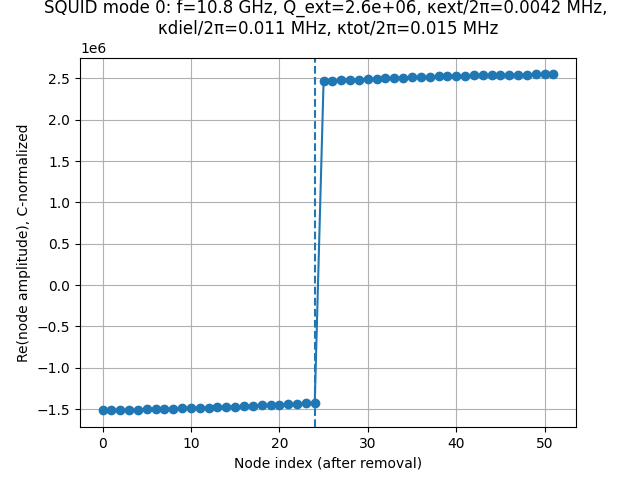

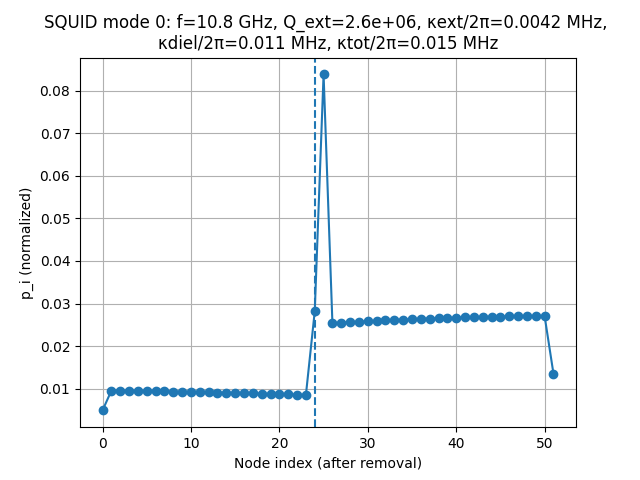

SQUID mode 1: f=36.79,2.91, MHz


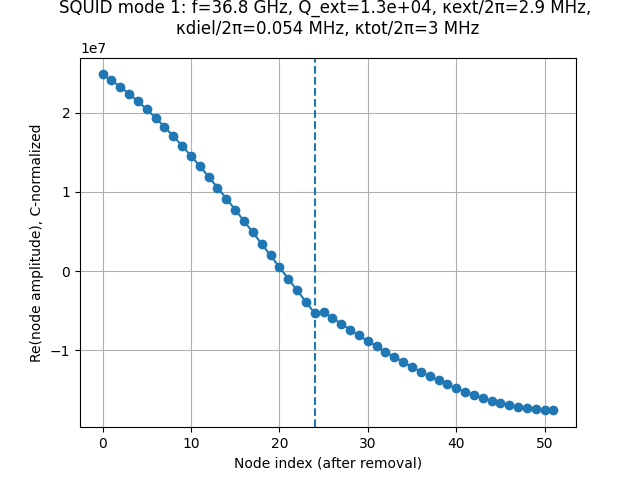

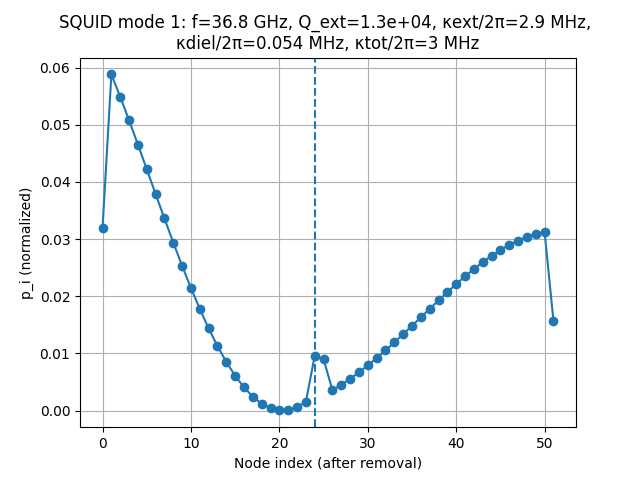

SQUID mode 2: f=42.33,0.0459, MHz


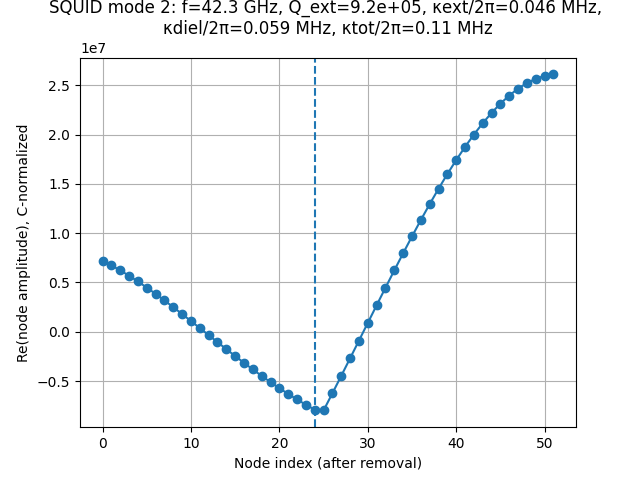

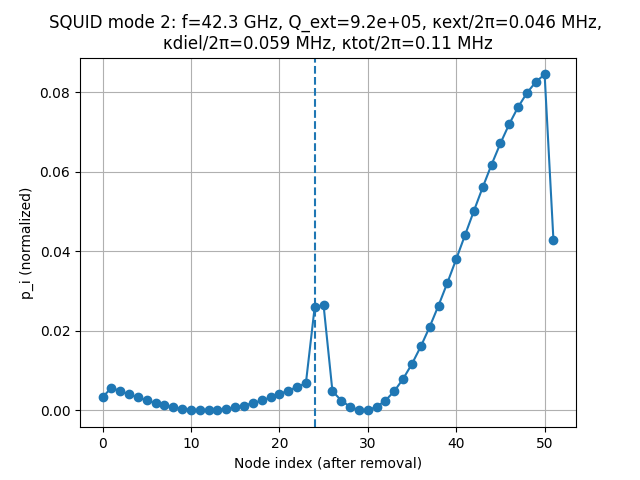

SQUID mode 3: f=48.03,0.0057, MHz


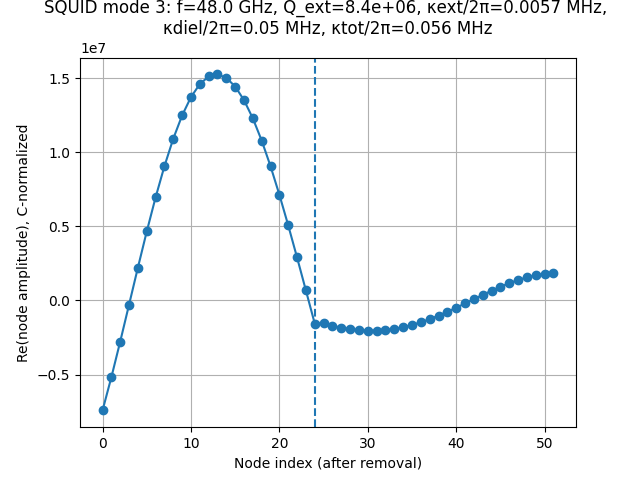

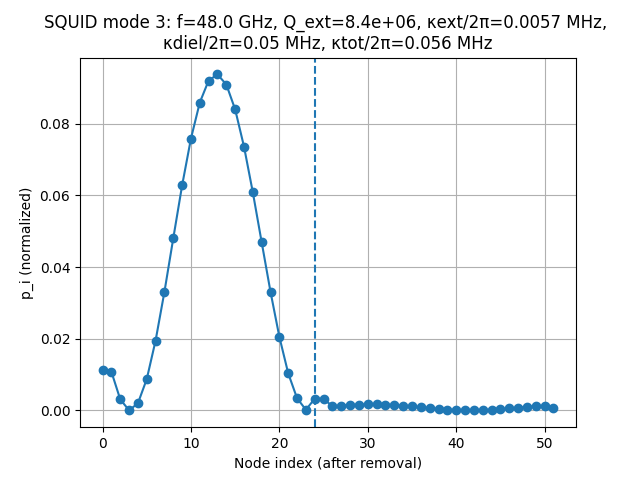

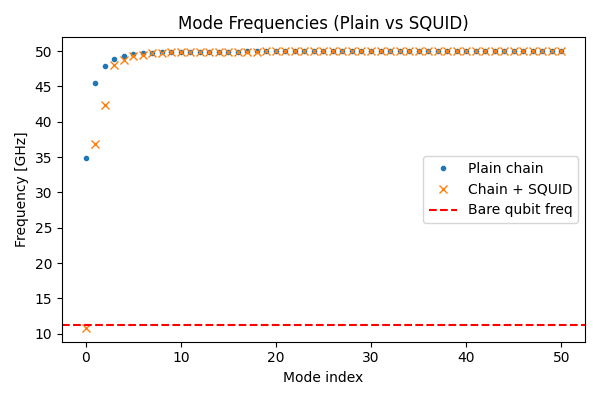

Computing Y_env(f)...


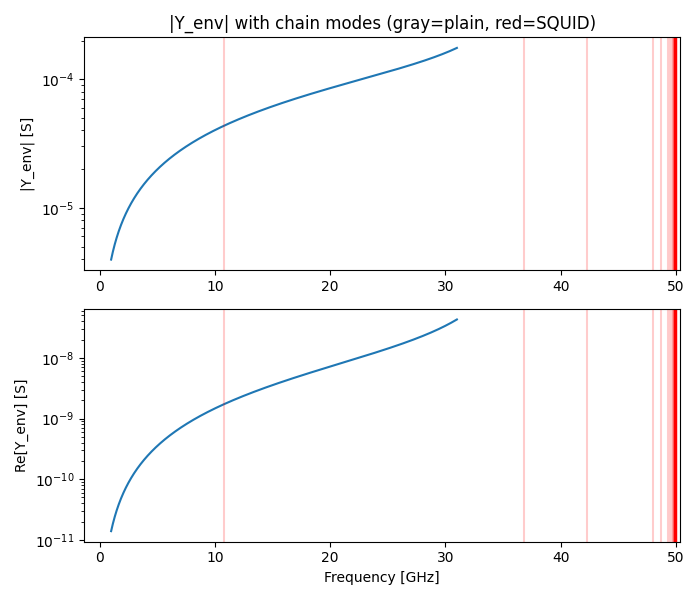

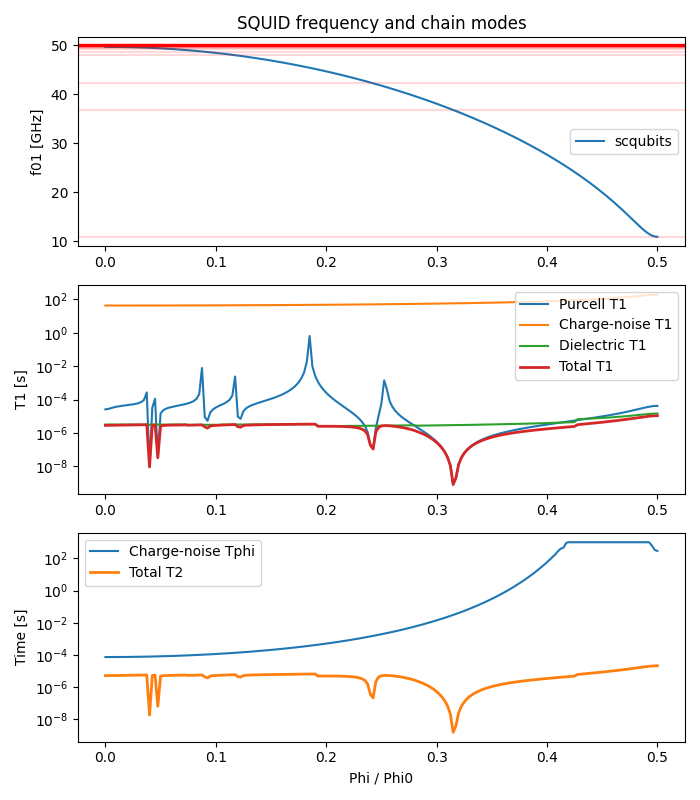

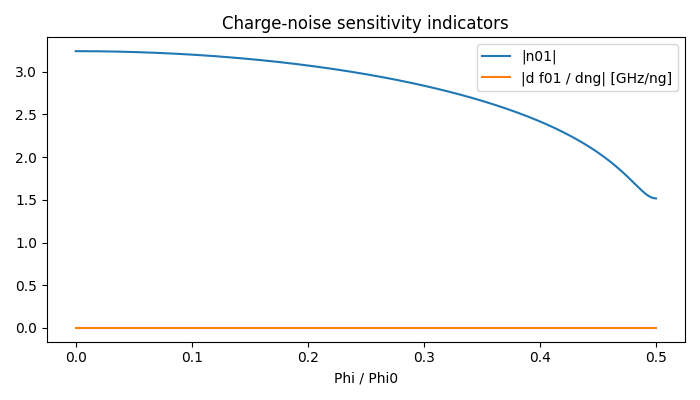

Purcell T1 41.82 , µs at Φ = 0.5 Φ0
Charge-noise Tphi 287123767.8 , µs at Φ = 0.5 Φ0
Dielectric T1 14.49 , µs at Φ = 0.5 Φ0


In [171]:
import numpy as np
import scipy.constants as const
import matplotlib.pyplot as plt
from numpy.linalg import inv, eig

# ======================================================================
# 0. CONSTANTS
# ======================================================================

h = const.h
e = const.e
pi = np.pi
Phi0 = h / (2 * e)   # flux quantum [Wb]


# ======================================================================
# 1. SQUID + TRANSMON BASICS  (USED FOR PURCELL, NOT FOR MATRIX MODES)
# ======================================================================

def squid_EJ_eff(EJ, d, Phi_ext):
    EJ1 = EJ * (1 + d)
    EJ2 = EJ * (1 - d)
    return np.sqrt(EJ1**2 + EJ2**2 + 2 * EJ1 * EJ2 * np.cos(2*pi*Phi_ext/Phi0))

def squid_LJ(EJ_eff):
    return Phi0**2 / (4 * pi**2 * EJ_eff)

def squid_plasma_freq(EJ_eff, Cq):
    Lj = squid_LJ(EJ_eff)
    return 1.0 / np.sqrt(Lj * Cq)       # [rad/s]


# ======================================================================
# 2. ENVIRONMENT ADMITTANCE (CORRECT NEW MODEL)
# ======================================================================


def Y_feedline(w, Cc, R):
    """
    Kept for compatibility / standalone use.

    Scalar feedline termination seen through a coupling capacitor:
      Z = R + 1/(j w Cc)  ->  Y = 1/Z
    """
    Cc = np.asarray(Cc, dtype=float)
    x = Cc * R * w
    return (Cc**2 * R * w**2 + 1j * Cc * w) / (1 + x**2)


def build_chain_admittance_matrix(N, L_sec, C_sec, Cg, Cc, R, w,
                                  break_middle=True, j_mid=None):
    """
    Admittance model consistent with build_chain_squid / build_chain_plain topology:

      node 0      : feed node
      nodes 1..N+1: chain nodes

    Chain branches:
      (1,2), (2,3), ..., (N,N+1)
      total = N branches

    If break_middle=True, the branch (j_mid, j_mid+1) is removed, so the
    differential admittance seen between those two nodes is the environment
    seen by the SQUID inserted there.

    Cg:
      - scalar: same shunt-to-ground on all chain nodes 1..N+1
      - array: expected to describe the regular chain nodes with the SQUID
               nodes removed; Cg_SQUID1 and Cg_SQUID2 are inserted at
               k = j_mid and k = j_mid+1

    Cc:
      - scalar: same behavior as your matrix builder => one capacitor between
                node 0 and node 1 only
      - array: expected to describe the regular chain nodes with the SQUID
               nodes removed; Cc_SQUID1 and Cc_SQUID2 are inserted at
               k = j_mid and k = j_mid+1

    Returns:
      Y, mid_left, mid_right
    """
    if j_mid is None:
        j_mid = N // 2

    mid_left, mid_right = j_mid, j_mid + 1

    # node 0 = feed, nodes 1..N+1 = chain
    n_nodes = N + 2
    Y = np.zeros((n_nodes, n_nodes), dtype=complex)

    # --------------------------------------------------
    # 1) Chain branches
    # --------------------------------------------------
    Y_sec = 1j * w * C_sec + 1.0 / (1j * w * L_sec)

    for j in range(1, N + 1):
        i1, i2 = j, j + 1

        if break_middle and j == j_mid:
            continue

        if j==j_mid-1:
            Y_sec = 1j * w * C_sec + 1.0 / (1j * w * (L_sec+40e-12))

        Y[i1, i1] += Y_sec
        Y[i2, i2] += Y_sec
        Y[i1, i2] -= Y_sec
        Y[i2, i1] -= Y_sec

        Y_sec = 1j * w * C_sec + 1.0 / (1j * w * L_sec)

    # --------------------------------------------------
    # 2) Shunt Cg to ground on chain nodes
    # --------------------------------------------------
    if np.isscalar(Cg):
        cg = float(Cg)
        Y_shunt = 1j * w * cg
        for k in range(1, N + 2):
            Y[k, k] += Y_shunt

    else:
        Cg_arr = np.asarray(Cg, dtype=float).ravel()

        for k in range(1, N + 2):
            # SQUID split nodes
            if k == mid_left:
                Y[k, k] += 1j * w * Cg_SQUID1
                continue
            elif k == mid_right:
                Y[k, k] += 1j * w * Cg_SQUID2
                continue

            # regular chain nodes, with the two SQUID nodes removed from the array
            if k < mid_left:
                cgk = Cg_arr[k - 1]
            else:  # k > mid_right
                cgk = Cg_arr[k - 3]

            Y[k, k] += 1j * w * cgk

    # --------------------------------------------------
    # 3) Feed coupling capacitors between node 0 and chain nodes
    # --------------------------------------------------
    if np.isscalar(Cc):
        # keep same semantics as build_chain_squid / build_chain_plain:
        # scalar Cc means only one capacitor between node 0 and node 1
        cc = float(Cc)
        ycc = 1j * w * cc

        Y[0, 0] += ycc
        Y[1, 1] += ycc
        Y[0, 1] -= ycc
        Y[1, 0] -= ycc

    else:
        Cc_arr = np.asarray(Cc, dtype=float).ravel()

        for k in range(1, N + 2):
            # SQUID split nodes
            if k == mid_left:
                cck = Cc_SQUID1
            elif k == mid_right:
                cck = Cc_SQUID2
            else:
                # regular chain nodes, with the two SQUID nodes removed from the array
                if k < mid_left:
                    cck = Cc_arr[k - 1]
                else:  # k > mid_right
                    cck = Cc_arr[k - 3]

            ycc = 1j * w * cck

            Y[0, 0] += ycc
            Y[k, k] += ycc
            Y[0, k] -= ycc
            Y[k, 0] -= ycc

    # --------------------------------------------------
    # 4) Feedline resistor to ground on node 0
    # --------------------------------------------------
    Y[0, 0] += 1.0 / R

    return Y, mid_left, mid_right


def Y_env_between_middle_nodes(N, L_sec, C_sec, Cg, Cc, R, w, j_mid=None):
    """
    Differential admittance seen between the two middle nodes where the SQUID sits.
    """
    Ymat, iL, iR = build_chain_admittance_matrix(
        N, L_sec, C_sec, Cg, Cc, R, w,
        break_middle=True, j_mid=j_mid
    )

    n = Ymat.shape[0]
    I = np.zeros(n, dtype=complex)
    I[iL] = 1.0
    I[iR] = -1.0

    V = np.linalg.solve(Ymat, I)
    Zenv = V[iL] - V[iR]
    return 1.0 / Zenv


def Y_env_spectrum(N, L_sec, C_sec, Cg, Cc, R, freqs, j_mid=None):
    out = []
    for f in freqs:
        w = 2 * pi * f
        out.append(Y_env_between_middle_nodes(N, L_sec, C_sec, Cg, Cc, R, w, j_mid=j_mid))
    return np.array(out)


#########################################################################

def make_tunable_transmon(qubit_params, flux, ng=None):
    """
    Helper constructor for scqubits TunableTransmon.
    flux in Weber; internally converted to Phi/Phi0.
    """
    return scq.TunableTransmon(
        EJmax=qubit_params['EJ_GHz'],
        EC=qubit_params['EC_GHz'],
        ng=qubit_params['ng'] if ng is None else ng,
        d=qubit_params['d'],
        ncut=qubit_params['ncut'],
        truncated_dim=qubit_params['truncated_dim'],
        flux=flux / Phi0,
    )


def transmon_observables(qubit_params, flux, ng=None):
    """
    Returns:
      w01   [rad/s]
      phi01 [dimensionless, via sin(phi) ~ phi]
      n01   [dimensionless charge matrix element]
      evals [GHz]
      evecs
    """
    qubit = make_tunable_transmon(qubit_params, flux, ng=ng)
    evals, evecs = qubit.eigensys(evals_count=3)

    # 0->1 transition in angular frequency
    w01 = 2 * pi * (evals[1] - evals[0]) * 1e9

    # small-phase proxy
    sinphi = qubit.sin_phi_operator()
    phi01 = (evecs[:, 0].conj().T @ sinphi @ evecs[:, 1]).item()

    # charge operator
    n_op = qubit.n_operator()
    n01 = (evecs[:, 0].conj().T @ n_op @ evecs[:, 1]).item()

    return w01, phi01, n01, evals, evecs


def transmon_charge_dispersion(qubit_params, flux):
    """
    Peak-to-peak 0->1 charge dispersion in [rad/s], estimated from ng = 0 and 0.5.
    This is usually a better measure of charge-noise sensitivity than a local derivative.
    """
    w_ng0, _, _, _, _ = transmon_observables(qubit_params, flux, ng=0.0)
    w_ng05, _, _, _, _ = transmon_observables(qubit_params, flux, ng=0.5)

    delta_omega_01 = np.abs(w_ng0 - w_ng05)
    return delta_omega_01

def EC_Joules_from_params(qubit_params):
    """
    Convert EC from GHz units to Joules.
    """
    return qubit_params['EC_GHz'] * h * 1e9


def gamma_charge_T1_from_Sng(qubit_params, n01, Sng_w01):
    """
    Charge-noise-induced relaxation rate from high-frequency charge-noise PSD.

    Parameters
    ----------
    Sng_w01 : float
        PSD of ng fluctuations at omega01, expressed as a PSD with respect
        to angular frequency omega. Treat as phenomenological input.

    Returns
    -------
    Gamma_1_ng [1/s], T1_ng [s]
    """
    ECJ = EC_Joules_from_params(qubit_params)
    Gamma = ((8 * ECJ) / hbar)**2 * (np.abs(n01)**2) * Sng_w01
    if Gamma <= 0:
        return 0.0, np.inf
    return Gamma, 1.0 / Gamma


def gamma_charge_dephasing_from_dispersion(delta_omega_01, sigma_ng_eff=1.0):
    """
    Charge-noise dephasing estimate from full charge dispersion.

    Parameters
    ----------
    delta_omega_01 : float
        Full 0->1 charge dispersion in rad/s:
            |omega01(ng=0) - omega01(ng=0.5)|

    sigma_ng_eff : float
        Effective fraction of the full dispersion sampled by slow ng fluctuations.
        Use:
          - 1.0 for a rough upper-scale estimate
          - smaller values (e.g. 0.01, 0.1) for a softer phenomenological estimate

    Returns
    -------
    Gamma_phi_ng [1/s], Tphi_ng [s]
    """
    Gamma_phi = np.abs(delta_omega_01) * sigma_ng_eff
    if Gamma_phi <= 0:
        return 0.0, np.inf
    return Gamma_phi, 1.0 / Gamma_phi


def combine_T1_Tphi(T1_purcell=np.inf, Gamma1_extra=0.0, Gamma_phi=0.0):
    """
    Combine Purcell T1 with extra relaxation and dephasing channels.

    Returns:
      Gamma1_tot, T1_tot, Gamma2_tot, T2_tot
    """
    Gamma1_p = 0.0 if not np.isfinite(T1_purcell) else 1.0 / T1_purcell
    Gamma1_tot = Gamma1_p + Gamma1_extra
    T1_tot = np.inf if Gamma1_tot <= 0 else 1.0 / Gamma1_tot

    Gamma2_tot = Gamma1_tot / 2.0 + Gamma_phi
    T2_tot = np.inf if Gamma2_tot <= 0 else 1.0 / Gamma2_tot

    return Gamma1_tot, T1_tot, Gamma2_tot, T2_tot


def Sng_white(S0):
    """
    White charge-noise PSD with respect to angular frequency omega.
    """
    return S0


def Sng_zero():
    """
    No high-frequency charge noise.
    """
    return 0.0



def purcell_gamma_T1(CJ, Cq, Yenv):
    ReY = np.real(Yenv)
    if ReY <= 0:
        return 0.0, np.inf
    Gamma = ReY / (2*CJ+Cq)
    return Gamma, 1/Gamma


def purcell_gamma_T1_qub(omega_q, phi01, Yenv):

    prefactor = hbar / (4 * e**2)  # ~1.0e3 in SI units (Ohms)   

    ReY = np.real(Yenv)
    if ReY <= 0:
        return 0.0, np.inf
    Gamma = prefactor * 2 * omega_q * (np.abs(phi01)**2) * ReY
    return Gamma, 1/Gamma

# ======================================================================
# 4. ORIGINAL MATRIX-CHAIN MODEL (FOR MODE SPECTRA ONLY)
# ======================================================================

def build_chain_plain(
    N,
    LJ,
    CJ,
    Cg,   # scalar OR array-like from HFSS (can be shorter than N)
    Cc,   # scalar OR array-like from HFSS (can be shorter than N)
    R,
):
    """
    Topology (unchanged):
      n = N + 2
        node 0 : strip/port (50Ω environment)
        node 1 : left pad / chain-end node used by LJ/CJ stamps
        nodes 2..N+1 : remaining chain islands

    JJ stamps (UNCHANGED):
      for j=1..N connect (j, j+1) with LJ and CJ.

    Updated only Cg & Cc handling:
      - Cg:
          * scalar: applied to nodes k=2..N+1
          * array-like: interpreted as per-node values for k=2..N+1 (length may be < N)
            If len(Cg_arr) < N, remaining nodes get 0.
      - Cc:
          * scalar: same capacitor value between node 0 and each node k=2..N+1
          * array-like: distributed coupling caps between node 0 and node k=2..N+1 (length may be < N)
            If len(Cc_arr) < N, remaining nodes get 0.

    Note: We do NOT use HFSS diagonals; we only stamp the selected mutuals (as caps).
    """
    n = N + 2
    K = np.zeros((n, n), dtype=float)
    C = np.zeros((n, n), dtype=float)
    G = np.zeros((n, n), dtype=float)

    # -----------------------------
    # JJ inductors & capacitors (UNCHANGED)
    # -----------------------------
    valL = 1.0 / LJ
    for j in range(1, N + 1):
        i1, i2 = j, j + 1
        K[i1, i1] += valL; K[i2, i2] += valL
        K[i1, i2] -= valL; K[i2, i1] -= valL

        C[i1, i1] += CJ;  C[i2, i2] += CJ
        C[i1, i2] -= CJ;  C[i2, i1] -= CJ

    # -----------------------------
    # Helper: fetch per-island value with zero-padding
    # -----------------------------
    def _as_array_or_none(x):
        return None if np.isscalar(x) else np.asarray(x, dtype=float).ravel()

    Cg_arr = _as_array_or_none(Cg)
    Cc_arr = _as_array_or_none(Cc)

    # -----------------------------
    # Shunt Cg on nodes k=2..N+1
    # -----------------------------
    if Cg_arr is None:
        cg = float(Cg)
        if cg != 0.0 or True:  # even if cg=0, we can still add it without harm; this simplifies the logic and avoids missing any nonzero entries due to a strict check
            for k in range(1, N + 2):
                C[k, k] += cg
    else:
        n_hfss = int(Cg_arr.size)
        # if shorter, missing nodes are treated as 0 automatically
        for idx, k in enumerate(range(1, N + 2)):  # idx=0..N-1
            if idx < n_hfss:
                cg = Cg_arr[idx]
                if cg != 0.0 or True:  # even if cg=0, we can still add it without harm; this simplifies the logic and avoids missing any nonzero entries due to a strict check
                    C[k, k] += cg
            # else: cg=0, do nothing

    # -----------------------------
    # Port coupling Cc between node 0 and nodes k=2..N+1
    # -----------------------------
    if Cc_arr is None:
        cc = float(Cc)
        if cc != 0.0 or True:  # even if cc=0, we can still add it without harm; this simplifies the logic and avoids missing any nonzero entries due to a strict check
            # for k in range(2, N + 2):
            C[0, 0] += cc
            C[1, 1] += cc
            C[0, 1] -= cc
            C[1, 0] -= cc
    else:
        n_hfss = int(Cc_arr.size)
        for idx, k in enumerate(range(1, N + 2)):  # idx=0..N-1
            if idx < n_hfss:
                cc = Cc_arr[idx]
                if cc != 0.0 or True:  # even if cc=0, we can still add it without harm; this simplifies the logic and avoids missing any nonzero entries due to a strict check
                    C[0, 0] += cc
                    C[k, k] += cc
                    C[0, k] -= cc
                    C[k, 0] -= cc
            # else: cc=0, do nothing
                # print(idx, k, cc/fF_to_F)

    # -----------------------------
    # Dissipation at port node
    # -----------------------------
    G[0, 0] = 1.0 / R

    return K, C, G


def build_chain_squid(N, LJ, CJ, Cg, Cc, R, qubit_params, Phi_ext, N_SQ=None):
    if N_SQ is None:
        N_SQ = N // 2

    w01, _,_,_,_ = transmon_observables(qubit_params, Phi_ext)

    CJ_s =qubit_params['CJ'] # total capacitance of the SQUID (two junctions in parallel)
    LJ_s = 1.0 / (w01**2 * CJ_s)

    n = N + 2
    K = np.zeros((n, n), dtype=float)
    C = np.zeros((n, n), dtype=float)
    G = np.zeros((n, n), dtype=float)

    # --------------------------------------------------
    # Inductors & capacitors, with one junction replaced by SQUID
    # (UNCHANGED logic for LJ/CJ vs LJ_s/CJ_s)
    # --------------------------------------------------
    for j in range(1, N + 1):
        # if j<N:    
        i1, i2 = j, j + 1

        if j == N_SQ:
            valL = 1.0 / LJ_s
            CJ_eff = CJ_s
        else:
            valL = 1.0 / LJ
            CJ_eff = CJ

        K[i1, i1] += valL; K[i2, i2] += valL
        K[i1, i2] -= valL; K[i2, i1] -= valL

        C[i1, i1] += CJ_eff; C[i2, i2] += CJ_eff
        C[i1, i2] -= CJ_eff; C[i2, i1] -= CJ_eff
    #     else:
    #         # Last junction replaced by a large island
    #         i1, i2 = N, N+1
            
    #         C_last_to_prelast = 0.16e-15
    #         CJ_eff = C_last_to_prelast

    #         C[i1, i1] += CJ_eff; C[i2, i2] += CJ_eff
    #         C[i1, i2] -= CJ_eff; C[i2, i1] -= CJ_eff

    # # last node to feed (large pad capacitance)
    # C_last_to_gnd = 9.17e-15
    # C[N+1, N+1] += C_last_to_gnd
    # C[0, 0] += C_last_to_gnd
    # C[0, N+1] -= C_last_to_gnd
    # C[N+1, 0] -= C_last_to_gnd

    # # last node to other nodes (stray capacitances)
    # C_last_to_others = 0.05e-15
    # for k in range(2, N + 1):
    #     C[k, k] += C_last_to_others
    #     C[k, N+1] -= C_last_to_others
    #     C[N+1, k] -= C_last_to_others
    #     C[N+1, N+1] += C_last_to_others

    # # last node to 1st island (stray capacitance)
    # C_last_to_first = 0.58e-15
    # C[1, 1] += C_last_to_first
    # C[1, N+1] -= C_last_to_first
    # C[N+1, 1] -= C_last_to_first
    # C[N+1, N+1] += C_last_to_first

    # --------------------------------------------------
    # UPDATED Cg handling (scalar OR array-like, can be shorter than N)
    # Applies to nodes k = 2..N+1 (N nodes)
    # Missing entries (if HFSS shorter) => treated as 0
    # --------------------------------------------------
    if np.isscalar(Cg):
        cg = float(Cg)
        if cg != 0.0 or True:  # even if cg=0, we can still add it without harm; this simplifies the logic and avoids missing any nonzero entries due to a strict check
            for k in range(1, N + 2):
                C[k, k] += cg
    else:
        Cg_arr = np.asarray(Cg, dtype=float).ravel()
        n_hfss = int(Cg_arr.size)
        for idx, k in enumerate(range(1, N + 2)):  # idx=0..N-1
            # if idx < n_hfss:
            if k == N_SQ:
                # print(f"Stamping Cg_SQUID={Cg_SQUID1} F at node {k}")
                C[k, k] += Cg_SQUID1
                continue
            elif k == N_SQ + 1:
                # print(f"Stamping Cg_SQUID={Cg_SQUID2} F at node {k}")
                C[k, k] += Cg_SQUID2
                continue
            
            cg = None
            if k > N_SQ + 1:
                cg = Cg_arr[idx-2]  # shift by 2 to account for the two middle nodes reserved for the qubit
            else:
                cg = Cg_arr[idx]


            if cg != 0.0 or True:  # even if cg=0, we can still add it without harm; this simplifies the logic and avoids missing any nonzero entries due to a strict check
                C[k, k] += cg
            # else: cg=0 -> do nothing

    # --------------------------------------------------
    # UPDATED Cc handling (scalar OR array-like, can be shorter than N)
    # Now: distributed coupling caps between port node 0 and nodes k = 2..N+1
    # Missing entries (if HFSS shorter) => treated as 0
    # --------------------------------------------------
    if np.isscalar(Cc):
        cc = float(Cc)
        if cc != 0.0 or True:  # even if cc=0, we can still add it without harm; this simplifies the logic and avoids missing any nonzero entries due to a strict check
            # for k in range(2, N + 2):
            C[0, 0] += cc
            C[1, 1] += cc
            C[0, 1] -= cc
            C[1, 0] -= cc
    else:
        Cc_arr = np.asarray(Cc, dtype=float).ravel()
        n_hfss = int(Cc_arr.size)
        for idx, k in enumerate(range(1, N + 2)):  # idx=0..N-1
            if k == N_SQ:
                # print(f"Stamping Cc_SQUID={Cc_SQUID1} F at node {k}")
                C[0, 0] += Cc_SQUID1
                C[k, k] += Cc_SQUID1
                C[0, k] -= Cc_SQUID1
                C[k, 0] -= Cc_SQUID1
                continue
            elif k == N_SQ + 1:
                # print(f"Stamping Cc_SQUID={Cc_SQUID2} F at node {k}")
                C[0, 0] += Cc_SQUID2
                C[k, k] += Cc_SQUID2
                C[0, k] -= Cc_SQUID2
                C[k, 0] -= Cc_SQUID2
                continue


            cc = None
            # if idx < n_hfss:
            if k > N_SQ + 1:
                cc = Cc_arr[idx-2]  # shift by 2 to account for the two middle nodes reserved for the qubit
            else:
                cc = Cc_arr[idx]
            if cc != 0.0 or True:  # even if cc=0, we can still add it without harm; this simplifies the logic and avoids missing any nonzero entries due to a strict check
                C[0, 0] += cc
                C[k, k] += cc
                C[0, k] -= cc
                C[k, 0] -= cc
            # else: cc=0 -> do nothing

            # print(idx, k, cc/fF_to_F)

    # --------------------------------------------------
    # Dissipation at port node
    # --------------------------------------------------
    G[0, 0] = 1.0 / R

    return K, C, G, LJ_s, CJ_s, N_SQ



def s21(K,C,G,R,freqs):
    n = C.shape[0]
    S = []
    b = np.zeros(n); b[0]=1/R
    for f in freqs:
        w = 2*np.pi*f
        M = K - w*w*C + 1j*w*G
        phi = np.linalg.solve(M,b)
        S.append(phi[-1])
    return np.array(S)

def s21_lossy(K, C, G, R, freqs, kappa_i=0, gamma_i=0):
    """
    Adds internal losses to:
        node 1 = resonator:  kappa_i
        node 2 = qubit:      gamma_i
    """

    n = C.shape[0]
    S_phi0 = []
    S_phi1 = []
    S_phi2 = []

    for f in freqs:
        w = 2*np.pi*f

        # copy G each iteration (never modify input)
        G_eff = G.copy()

        # Add internal loss conductances:
        # physically, G has units of siemens (Ohm^-1)
        # damping term is (i*ω)*G in the equations.
        G_eff[1,1] += kappa_i / w       # resonator intrinsic loss
        G_eff[N//2,N//2] += gamma_i / w       # qubit intrinsic loss

        # Standard solve
        b = np.zeros(n)
        b[0] = 1/R

        M = K - w*w*C + 1j*w*G_eff
        phi = np.linalg.solve(M, b)
        S_phi0.append(phi[0])  # measure at port node
        S_phi1.append(phi[1])  # measure at resonator node
        S_phi2.append(phi[N//2])  # measure at resonator node (or phi[-1] if you want qubit node)

    return np.array(S_phi0), np.array(S_phi1), np.array(S_phi2)


def build_A(K,C,G):
    n = C.shape[0]
    Cinv = inv(C)
    zero = np.zeros((n,n))
    I = np.eye(n)
    A = np.block([[zero, I], [-Cinv@K, -Cinv@G]])
    return A

def compute_modes(A):
    lam, vec = eig(A)
    mask = np.imag(lam) > 0
    lam = lam[mask]
    vec = vec[:,mask]
    order = np.argsort(np.imag(lam))
    lam = lam[order]
    vec = vec[:,order]

    omega = np.imag(lam)
    freqs = omega/(2*pi)
    Q = omega / (2*(-np.real(lam)))
    return freqs, Q, lam, vec


def compare_modes(freqs_plain, freqs_squid, f_q):
    plt.figure(figsize=(6,4))
    plt.plot(freqs_plain/1e9, '.', label='Plain chain')
    plt.plot(freqs_squid/1e9, 'x', label='Chain + SQUID')
    plt.axhline(f_q/1e9, color='r', linestyle='--', label='Bare qubit freq')
    plt.xlabel("Mode index")
    plt.ylabel("Frequency [GHz]")
    plt.legend()
    plt.title("Mode Frequencies (Plain vs SQUID)")
    plt.tight_layout()
    plt.show()


# ======================================================================
# 4.5 DIELECTRIC PARTICIPATION + Q_diel + T1_diel
# ======================================================================
def _extract_node_block_from_state_evecs(evecs, n_nodes, which="first"):
    V = np.array(evecs, dtype=complex)
    if V.shape[0] == n_nodes:
        return V
    if V.shape[0] == 2 * n_nodes:
        return V[:n_nodes, :] if which == "first" else V[-n_nodes:, :]
    raise ValueError(f"Unexpected evecs shape {V.shape}; expected {n_nodes} or {2*n_nodes} rows.")

#############################
# MODE ANALYSIS
#############################
# ============================================================
# DROP-IN: add kappa (and kappa/2pi in MHz) to the mode-shape plots
# Works with your existing freq[], Q[] arrays (from compute_modes).
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

def _C_normalize_modes(V_nodes, C_nodes):
    V = np.array(V_nodes, dtype=complex, copy=True)
    for k in range(V.shape[1]):
        vk = V[:, k]
        nk = np.sqrt(np.abs(vk.conj().T @ (C_nodes @ vk)))
        if nk > 0:
            V[:, k] = vk / nk
    return V

def _mode_participation(v, C):
    Cdiag = np.real(np.diag(C))
    p = (np.abs(v)**2) * np.maximum(Cdiag, 0.0)
    s = p.sum()
    return p / s if s > 0 else p

def analyze_and_plot_modes(tag, C, freq, Q, evecs, idx_squid=None,
                           n_show=6, remove_nodes=(0,), start_mode=0,
                           state_node_block="first"):
    """
    Adds kappa on plot titles:
      kappa = omega / Q  (rad/s)
      kappa/2pi = f / Q  (Hz)
    Uses freq in Hz (as returned by your compute_modes).
    """
    global MODE_IDX, FREQ1, FREQ2, KAPPA

    n = C.shape[0]

    # Extract node-component eigenvectors if evecs are for state-space A
    Vnodes_full = _extract_node_block_from_state_evecs(evecs, n_nodes=n, which=state_node_block)

    keep = np.ones(n, dtype=bool)
    for rn in remove_nodes:
        if 0 <= rn < n:
            keep[rn] = False

    Ck = C[np.ix_(keep, keep)]
    Vk = Vnodes_full[keep, :]
    Vk = _C_normalize_modes(Vk, Ck)

    nodes_kept = np.where(keep)[0]
    mode_ids = list(range(start_mode, min(start_mode + n_show, Vk.shape[1])))

    squid_plot_idx = None
    if idx_squid is not None and 0 <= idx_squid < n and keep[idx_squid]:
        squid_plot_idx = np.where(nodes_kept == idx_squid)[0][0]

    for m in mode_ids:
        v = Vk[:, m]

        # Choose a consistent global phase for pretty plots
        imax = np.argmax(np.abs(v))
        phase = np.exp(-1j * np.angle(v[imax])) if np.abs(v[imax]) > 0 else 1.0
        v = v * phase

        v_plot = np.real(v)
        p = _mode_participation(v, Ck)

        f_Hz = float(freq[m]) if np.isfinite(freq[m]) else np.nan
        Qm = float(Q[m]) if np.isfinite(Q[m]) else np.nan

        # kappa from Q and freq (no need for evals):
        # kappa/2pi (Hz) = f / Q
        # kappa (rad/s) = 2pi f / Q
        if np.isfinite(f_Hz) and np.isfinite(Qm) and Qm > 0:
            kappa_over_2pi_Hz = f_Hz / Qm
            kappa_over_2pi_MHz = kappa_over_2pi_Hz / 1e6
        else:
            kappa_over_2pi_MHz = np.nan



                # dielectric contribution for this mode if available
        if tag == "SQUID" and m < len(diel_summary_squid):
            Q_diel_m = diel_summary_squid[m]["Q_diel"]
            kappa_diel_over_2pi_MHz = diel_summary_squid[m]["kappa_diel_over_2pi_Hz"] / 1e6

            if np.isfinite(Q_diel_m) and Q_diel_m > 0 and np.isfinite(Qm) and Qm > 0:
                # Qm from eigenvalues is your current external / loaded value from G=1/R only
                # combine linewidths, not Qs, because kappas add
                kappa_ext_over_2pi_Hz = f_Hz / Qm
                kappa_tot_over_2pi_MHz = (kappa_ext_over_2pi_Hz + diel_summary_squid[m]["kappa_diel_over_2pi_Hz"]) / 1e6
            else:
                kappa_diel_over_2pi_MHz = np.nan
                kappa_tot_over_2pi_MHz = np.nan
        else:
            kappa_diel_over_2pi_MHz = np.nan
            kappa_tot_over_2pi_MHz = np.nan




        fGHz = f_Hz / 1e9 if np.isfinite(f_Hz) else np.nan

        print(f"{tag} mode {m}: f={fGHz:.2f},{kappa_over_2pi_MHz:.3g}, MHz")

        if m==0 and (fGHz < 0.5):
            MODE_IDX += 1
            print(f"  Warning: mode {m} has out-of-range frequency {fGHz:.2f} GHz; check if it's a physical mode or a numerical artifact.")

        elif m == MODE_IDX:
            FREQ1 = fGHz
            KAPPA = kappa_over_2pi_MHz
        elif m == MODE_IDX+1:
            FREQ2 = fGHz

        # --- Mode shape plot ---
        plt.figure()
        plt.plot(v_plot, marker="o")
        if squid_plot_idx is not None:
            plt.axvline(squid_plot_idx, linestyle="--")
        plt.title(
            f"{tag} mode {m}: f={fGHz:.1f} GHz, "
            f"Q_ext={Qm:.2g}, "
            f"κext/2π={kappa_over_2pi_MHz:.2g} MHz, "
            "\n"
            f"κdiel/2π={kappa_diel_over_2pi_MHz:.2g} MHz, "
            f"κtot/2π={kappa_tot_over_2pi_MHz:.2g} MHz"
        )
        plt.xlabel("Node index (after removal)")
        plt.ylabel("Re(node amplitude), C-normalized")
        plt.grid(True)
        plt.show()

        # --- Participation plot ---
        plt.figure()
        plt.plot(p, marker="o")
        if squid_plot_idx is not None:
            plt.axvline(squid_plot_idx, linestyle="--")
        plt.title(
            f"{tag} mode {m}: f={fGHz:.1f} GHz, "
            f"Q_ext={Qm:.2g}, "
            f"κext/2π={kappa_over_2pi_MHz:.2g} MHz, "
            "\n"
            f"κdiel/2π={kappa_diel_over_2pi_MHz:.2g} MHz, "
            f"κtot/2π={kappa_tot_over_2pi_MHz:.2g} MHz"
        )
        plt.xlabel("Node index (after removal)")
        plt.ylabel("p_i (normalized)")
        plt.grid(True)
        plt.show()


def _extract_node_evecs_for_modes(Cmat, evecs, remove_feed=True, state_node_block="first"):
    """
    Returns node eigenvectors (columns = modes) in the physical node basis.
    Compatible with the state-space eigenvectors returned by compute_modes/build_A.
    """
    n = Cmat.shape[0]
    Vnodes_full = _extract_node_block_from_state_evecs(evecs, n_nodes=n, which=state_node_block)

    if remove_feed:
        keep = np.ones(n, dtype=bool)
        keep[0] = False
        Ck = Cmat[np.ix_(keep, keep)]
        Vk = Vnodes_full[keep, :]
        node_labels = np.arange(1, n)
    else:
        Ck = Cmat
        Vk = Vnodes_full
        node_labels = np.arange(n)

    Vk = _C_normalize_modes(Vk, Ck)
    return Ck, Vk, node_labels


def _regular_chain_caps_with_squid_nodes(N, arr_regular, N_SQ, val_sq_left, val_sq_right):
    """
    Build a full length-(N+1) array for chain nodes 1..N+1, inserting the two SQUID-node values
    at N_SQ and N_SQ+1, while arr_regular contains all the OTHER chain-node values.
    """
    out = np.zeros(N + 1, dtype=float)
    arr_regular = np.asarray(arr_regular, dtype=float).ravel()

    ptr = 0
    for k in range(1, N + 2):
        if k == N_SQ:
            out[k - 1] = val_sq_left
        elif k == N_SQ + 1:
            out[k - 1] = val_sq_right
        else:
            if ptr < len(arr_regular):
                out[k - 1] = arr_regular[ptr]
                ptr += 1
            else:
                out[k - 1] = 0.0
    return out


def mode_dielectric_participations(v_nodes, N, CJ, Cg_arr_full, CJ_s, N_SQ):
    """
    v_nodes: node-mode vector WITHOUT feed node, ordered as physical chain nodes 1..N+1.
             length = N+1

    Returns electric-energy participations:
      p_Cg       : silicon / shunt-ground participation
      p_CJ_reg   : regular JJ dielectric participation
      p_CJ_sq    : SQUID junction dielectric participation
      p_tot      : should be ~1 for the purely electric partition used here
    """
    v = np.asarray(v_nodes, dtype=complex)
    assert v.shape[0] == N + 1

    # Shunt-to-ground electric energy
    U_Cg = np.sum(Cg_arr_full * np.abs(v)**2)

    # Junction-capacitor electric energy on regular branches
    U_CJ_reg = 0.0
    U_CJ_sq = 0.0

    for j in range(1, N + 1):
        dv2 = np.abs(v[j - 1] - v[j])**2
        if j == N_SQ:
            U_CJ_sq += CJ_s * dv2
        else:
            U_CJ_reg += CJ * dv2

    U_E = U_Cg + U_CJ_reg + U_CJ_sq

    if U_E <= 0:
        return {
            "p_Cg": 0.0,
            "p_CJ_reg": 0.0,
            "p_CJ_sq": 0.0,
            "p_tot": 0.0,
            "U_Cg": 0.0,
            "U_CJ_reg": 0.0,
            "U_CJ_sq": 0.0,
            "U_E": 0.0,
        }

    return {
        "p_Cg": U_Cg / U_E,
        "p_CJ_reg": U_CJ_reg / U_E,
        "p_CJ_sq": U_CJ_sq / U_E,
        "p_tot": (U_Cg + U_CJ_reg + U_CJ_sq) / U_E,
        "U_Cg": U_Cg,
        "U_CJ_reg": U_CJ_reg,
        "U_CJ_sq": U_CJ_sq,
        "U_E": U_E,
    }


def dielectric_Q_from_participation(parts, tan_delta_Si, tan_delta_JJ, tan_delta_SQUID=None):
    """
    Compute Q_diel from participations and loss tangents.
    """
    if tan_delta_SQUID is None:
        tan_delta_SQUID = tan_delta_JJ

    invQ = (
        parts["p_Cg"] * tan_delta_Si
        + parts["p_CJ_reg"] * tan_delta_JJ
        + parts["p_CJ_sq"] * tan_delta_SQUID
    )

    if invQ <= 0:
        return np.inf
    return 1.0 / invQ


def dielectric_kappa_from_Q(freq_Hz, Q_diel):
    """
    Returns kappa_diel in rad/s and kappa_diel/2pi in Hz.
    """
    if not np.isfinite(Q_diel) or Q_diel <= 0:
        return 0.0, 0.0
    kappa_over_2pi = freq_Hz / Q_diel
    kappa = 2 * pi * kappa_over_2pi
    return kappa, kappa_over_2pi


def dielectric_mode_summary(N, Cmat, evecs, freqs, CJ, Cg_array, CJ_s, N_SQ,
                            tan_delta_Si, tan_delta_JJ, tan_delta_SQUID=None,
                            state_node_block="first"):
    """
    Compute dielectric participations and Q_diel for all modes.
    """
    Ck, Vk, node_labels = _extract_node_evecs_for_modes(
        Cmat, evecs, remove_feed=True, state_node_block=state_node_block
    )

    # Build full chain-node Cg array including the two SQUID nodes
    Cg_full = _regular_chain_caps_with_squid_nodes(
        N, Cg_array, N_SQ, Cg_SQUID1, Cg_SQUID2
    )

    out = []
    for m in range(Vk.shape[1]):
        v = Vk[:, m]   # length N+1, nodes 1..N+1
        parts = mode_dielectric_participations(v, N, CJ, Cg_full, CJ_s, N_SQ)
        Q_diel = dielectric_Q_from_participation(
            parts, tan_delta_Si, tan_delta_JJ, tan_delta_SQUID=tan_delta_SQUID
        )
        kappa_diel, kappa_diel_over_2pi = dielectric_kappa_from_Q(freqs[m], Q_diel)

        out.append({
            "mode": m,
            "freq_Hz": freqs[m],
            "Q_diel": Q_diel,
            "kappa_diel": kappa_diel,
            "kappa_diel_over_2pi_Hz": kappa_diel_over_2pi,
            **parts
        })
    return out


def T1_dielectric_from_Q_and_freq(freq_Hz, Q_diel):
    """
    For a dielectric-limited oscillator-like loss channel:
        T1 = Q / omega
    """
    if not np.isfinite(Q_diel) or Q_diel <= 0 or freq_Hz <= 0:
        return np.inf
    omega = 2 * pi * freq_Hz
    return Q_diel / omega

def dielectric_gamma_T1_from_Q(freq_Hz, Q_diel):
    """
    Gamma = omega / Q_diel
    """
    if not np.isfinite(Q_diel) or Q_diel <= 0 or freq_Hz <= 0:
        return 0.0, np.inf
    omega = 2 * pi * freq_Hz
    Gamma = omega / Q_diel
    return Gamma, 1.0 / Gamma


# ======================================================================
# 5. MAIN SCRIPT (INTEGRATED)
# ======================================================================


# Flux sweep
Phi_list = np.linspace(0, 0.5*Phi0, 201)

# Frequency span for Y_env
f_span = np.linspace(1e9, 31e9, 2000)


# ======================================================================
# 5.1 COMPUTE MATRIX MODES (REFERENCE FOR PLOTS)
# ======================================================================

print("Computing matrix-chain modes (plain)...")
# Kp,Cp,Gp = build_chain_plain(N, LJ, CJ, Cg, Cc, R)
Kp,Cp,Gp = build_chain_plain(N, LJ, CJ, Cg_array, Cc_array, R)
Ap = build_A(Kp,Cp,Gp)
freq_plain, Q_plain, evals_plain, evecs_plain = compute_modes(Ap)

print("Computing matrix-chain modes (with SQUID)...")
Ks,Cs,Gs, LJ_s, CJ_s, idx_squid = build_chain_squid(
    N, LJ, CJ, Cg_array, Cc_array, R, qubit_params, Phi_list[-1], N_SQ=N_SQUID
)
As = build_A(Ks,Cs,Gs)
freq_squid, Q_squid, evals_squid, evecs_squid = compute_modes(As)


# ======================================================================
# 5.1b DIELECTRIC MODE LOSS SUMMARY
# ======================================================================

diel_summary_squid = dielectric_mode_summary(
    N=N,
    Cmat=Cs,
    evecs=evecs_squid,
    freqs=freq_squid,
    CJ=CJ,
    Cg_array=Cg_array,
    CJ_s=CJ_s,
    N_SQ=N_SQUID,
    tan_delta_Si=tan_delta_Si,
    tan_delta_JJ=tan_delta_JJ,
    tan_delta_SQUID=tan_delta_SQUID,
    state_node_block="first",
)

for row in diel_summary_squid[:6]:
    print(
        f"mode {row['mode']}: "
        f"f={row['freq_Hz']/1e9:.3f} GHz, "
        f"Q_diel={row['Q_diel']:.3g}, "
        f"kappa_diel/2pi={row['kappa_diel_over_2pi_Hz']/1e6:.3g} MHz, "
        f"p_Cg={row['p_Cg']:.3f}, "
        f"p_CJ_reg={row['p_CJ_reg']:.3f}, "
        f"p_CJ_sq={row['p_CJ_sq']:.3f}"
    )





# =======================
# Use it (drop-in)
# =======================
# analyze_and_plot_modes(
#     tag="PLAIN",
#     C=Cp,
#     freq=freq_plain, Q=Q_plain,
#     evecs=evecs_plain,
#     idx_squid=None,
#     n_show=6,
#     remove_nodes=(0,),
#     start_mode=0,
#     state_node_block="first"   # if shapes look wrong, switch to "last"
# )

analyze_and_plot_modes(
    tag="SQUID",
    C=Cs,
    freq=freq_squid, Q=Q_squid,
    evecs=evecs_squid,
    idx_squid=idx_squid,
    n_show=4,
    remove_nodes=(0,),
    start_mode=0,
    state_node_block="first"   # if shapes look wrong, switch to "last"
)
# np.save("modes_plain.npy", evals_plain)
# np.save("modes_squid.npy", evals_squid)




EJ_eff = squid_EJ_eff(EJ, d, Phi_list[-1])
wq = squid_plasma_freq(EJ_eff, 2*CJ)   # Cq = 2*CJ here
compare_modes(freq_plain, freq_squid, wq/(2*pi))

# ======================================================================
# 5.2 ENVIRONMENT ADMITTANCE SPECTRUM
# ======================================================================

print("Computing Y_env(f)...")
try:
    Y_env = Y_env_spectrum(N, LJ, CJ, Cg_array, Cc_array, R, f_span, j_mid=N_SQUID)
except Exception as e:
    print(f"Error computing Y_env: {e}")
    Y_env = np.zeros_like(f_span, dtype=complex)

plt.figure(figsize=(7,6))
plt.subplot(2,1,1)
plt.semilogy(f_span*1e-9, np.abs(Y_env))
# for f in freq_plain:
#     plt.axvline(f*1e-9, color='gray', alpha=0.2)
for f in freq_squid:
    plt.axvline(f*1e-9, color='red', alpha=0.2)
plt.title("|Y_env| with chain modes (gray=plain, red=SQUID)")
plt.ylabel("|Y_env| [S]")

plt.subplot(2,1,2)
plt.plot(f_span*1e-9, np.real(Y_env))
# for f in freq_plain:
#     plt.axvline(f*1e-9, color='gray', alpha=0.2)
for f in freq_squid:
    plt.axvline(f*1e-9, color='red', alpha=0.2)
plt.yscale("log")
plt.xlabel("Frequency [GHz]")
plt.ylabel("Re[Y_env] [S]")
plt.tight_layout()
plt.show()


# ======================================================================
# 5.3 QUBIT FREQUENCY & PURCELL T1(Φ)
# ======================================================================

f_q_list = []
f_q_list_scq = []
# T1_list = []
T1_list_qub = []

T1_charge_list = []
Tphi_charge_list = []
T1_diel_list = []
T1_total_list = []
T2_total_list = []
n01_list = []
domega_dng_list = []


for Phi in Phi_list:
    # SQUID/transmon observables from scqubits
    w01, phi01, n01, evals_q, evecs_q = transmon_observables(qubit_params, Phi)
    domega_dng = transmon_charge_dispersion(qubit_params, Phi)

    f_q_list_scq.append(w01 / (2*pi))
    n01_list.append(np.abs(n01))
    domega_dng_list.append(domega_dng)

    # Simple SQUID formula for comparison only
    EJ_eff = squid_EJ_eff(EJ, d, Phi)
    wq = squid_plasma_freq(EJ_eff, CJ*2)
    fq = wq / (2*pi)
    f_q_list.append(fq)

    # try:
    # Purcell from the chain environment
    Yenv_q = Y_env_between_middle_nodes(N, LJ, CJ, Cg_array, Cc_array, R, w01, j_mid=N_SQUID)
    Gamma_purcell, T1_purcell = purcell_gamma_T1_qub(w01, phi01, Yenv_q)
    # except Exception as e:
    #     print(f"Error computing Yenv / Purcell for Phi={Phi}: {e}")
    #     Gamma_purcell, T1_purcell = 0.0, np.inf

    # Dielectric T1 estimate:
    # use the closest hybridized SQUID+chain mode in frequency
    mode_idx_closest = np.argmin(np.abs(freq_squid - w01/(2*pi)))
    Q_diel_q = diel_summary_squid[mode_idx_closest]["Q_diel"]
    Gamma_diel, T1_diel = dielectric_gamma_T1_from_Q(w01/(2*pi), Q_diel_q)

    # -----------------------------
    # Charge-noise assumptions
    # -----------------------------
    # High-frequency PSD at omega01: unknown -> phenomenological fit parameter
    Sng_w01 = Sng_white(1e-23)          # offset-charge noise scaling roughly as 1 / 𝑓 𝛼 1/f α with 𝛼 ≈ 1.93 α≈1.93 and 𝑆 𝑞 ( 1 H z ) = 2.9 × 10 − 4 𝑒 2 / H z S q ​ (1Hz)=2.9×10 −4 e 2 /Hz

    # Slow rms offset-charge fluctuation for dephasing
    sigma_ng = 0.5              # example placeholder; treat as fit parameter

    Gamma1_ng, T1_ng = gamma_charge_T1_from_Sng(qubit_params, n01, Sng_w01)
    Gamma_phi_ng, Tphi_ng = gamma_charge_dephasing_from_dispersion(domega_dng, sigma_ng_eff=sigma_ng)


    Gamma1_tot, T1_tot, Gamma2_tot, T2_tot = combine_T1_Tphi(
        T1_purcell=T1_purcell,
        Gamma1_extra=Gamma1_ng + Gamma_diel,
        Gamma_phi=Gamma_phi_ng
    )

    # Clip for plotting
    T1_purcell = np.clip(T1_purcell, 0, 1e3)
    T1_ng = np.clip(T1_ng, 0, 1e3)
    Tphi_ng = np.clip(Tphi_ng, 0, 1e3)
    T1_tot = np.clip(T1_tot, 0, 1e3)
    T2_tot = np.clip(T2_tot, 0, 1e3)
    T1_diel = np.clip(T1_diel, 0, 1e3)


    T1_list_qub.append(T1_purcell)
    T1_charge_list.append(T1_ng)
    Tphi_charge_list.append(Tphi_ng)
    T1_total_list.append(T1_tot)
    T2_total_list.append(T2_tot)
    T1_diel_list.append(T1_diel)


f_q_list = np.array(f_q_list)
f_q_list_scq = np.array(f_q_list_scq)
# T1_list = np.array(T1_list)
T1_list_qub = np.array(T1_list_qub)

T1_charge_list = np.array(T1_charge_list)
Tphi_charge_list = np.array(Tphi_charge_list)
T1_total_list = np.array(T1_total_list)
T2_total_list = np.array(T2_total_list)
T1_diel_list = np.array(T1_diel_list)
n01_list = np.array(n01_list)
domega_dng_list = np.array(domega_dng_list)


# plt.figure(figsize=(7,6))

# plt.subplot(2,1,1)
# plt.plot(Phi_list/Phi0, f_q_list*1e-9, label='simple SQUID')
# plt.plot(Phi_list/Phi0, f_q_list_scq*1e-9, linestyle='--', label='scqubits')
# for f in freq_squid:
#     plt.axhline(f*1e-9, color='red', alpha=0.15)
# plt.legend()
# plt.ylabel("Qubit f(Φ) [GHz]")
# plt.title("Qubit frequency & chain+SQUID modes (red lines)")

# plt.subplot(2,1,2)
# # plt.semilogy(Phi_list/Phi0, T1_list, label='simple SQUID')
# plt.semilogy(Phi_list/Phi0, T1_list_qub, linestyle='--', label='scqubits')
# # for f in freq_squid:
# #     plt.axhline(1e-6, color='red', alpha=0.05)   # Just visual grid
# plt.xlabel("Φ/Φ0")
# plt.ylabel("Purcell T1(Φ) [s]")
# plt.tight_layout()
# plt.show()



plt.figure(figsize=(7,8))

plt.subplot(3,1,1)
plt.plot(Phi_list/Phi0, f_q_list_scq*1e-9, label='scqubits')
for f in freq_squid:
    plt.axhline(f*1e-9, color='red', alpha=0.15)
plt.ylabel("f01 [GHz]")
plt.legend()
plt.title("SQUID frequency and chain modes")

plt.subplot(3,1,2)
plt.semilogy(Phi_list/Phi0, T1_list_qub, label='Purcell T1')
plt.semilogy(Phi_list/Phi0, T1_charge_list, label='Charge-noise T1')
plt.semilogy(Phi_list/Phi0, T1_diel_list, label='Dielectric T1')
plt.semilogy(Phi_list/Phi0, T1_total_list, label='Total T1', linewidth=2)
plt.ylabel("T1 [s]")
plt.legend()

plt.subplot(3,1,3)
plt.semilogy(Phi_list/Phi0, Tphi_charge_list, label='Charge-noise Tphi')
plt.semilogy(Phi_list/Phi0, T2_total_list, label='Total T2', linewidth=2)
plt.xlabel("Phi / Phi0")
plt.ylabel("Time [s]")
plt.legend()

plt.tight_layout()
plt.show()


plt.figure(figsize=(7,4))
plt.plot(Phi_list/Phi0, n01_list, label='|n01|')
plt.plot(Phi_list/Phi0, np.abs(domega_dng_list)/(2*pi*1e9), label='|d f01 / dng| [GHz/ng]')
plt.xlabel("Phi / Phi0")
plt.legend()
plt.title("Charge-noise sensitivity indicators")
plt.tight_layout()
plt.show()



print("Purcell T1", round(T1_list_qub[-1]*1e6, 2), ", µs at Φ =", round(Phi_list[-1]/Phi0, 2), "Φ0")

T1_PURCELL = T1_list_qub[-1]*1e6

print("Charge-noise Tphi", round(Tphi_charge_list[-1]*1e6, 2), ", µs at Φ =", round(Phi_list[-1]/Phi0, 2), "Φ0")

TPHI_CHARGE = Tphi_charge_list[-1]*1e6

print("Dielectric T1", round(T1_diel_list[-1]*1e6, 2), ", µs at Φ =", round(Phi_list[-1]/Phi0, 2), "Φ0")
T1_DIEL = T1_diel_list[-1]*1e6

In [172]:
round(FREQ1,2), round(KAPPA,2), float(round(T1_PURCELL,2))

(36.79, 2.91, 41.82)

In [173]:

from tqdm import tqdm
###############################################################################
# MAIN SIMULATION LOOP
###############################################################################

# Phi_list = np.linspace(0, 0.5*Phi0, 1001)
# f_span = np.linspace(8e9, 31e9, 5000)

Phi_list = np.linspace(0.1*Phi0, 0.5*Phi0, 801)
f_span = np.linspace(FREQ1*1e9-3e9, FREQ1*1e9+3e9, 500)
# f_span = np.linspace(10e9, 31e9, 500)


S_phi0 = np.zeros((len(Phi_list), len(f_span)), dtype=complex)
S_phi1 = np.zeros((len(Phi_list), len(f_span)), dtype=complex)
S_phi2 = np.zeros((len(Phi_list), len(f_span)), dtype=complex)

f_q_list = []
f_q_list_scq = []

for i, Phi in enumerate(tqdm(Phi_list)):

    w01, phi01, _, _, _ = transmon_observables(qubit_params, Phi)
    f_q_list_scq.append(w01/(2*pi))

    # Using our simple SQUID formulas for comparison
    EJ_eff = squid_EJ_eff(EJ, d, Phi)
    wq = squid_plasma_freq(EJ_eff, CJ*2)
    fq = wq/(2*pi)
    f_q_list.append(fq)

    Ks,Cs,Gs, LJ_s, CJ_s, idx_squid = build_chain_squid(
        N, LJ, CJ, Cg_array, Cc_array, R, qubit_params, Phi, N_SQ=N_SQUID
    )

    kappa_i = 0#2*np.pi*1e3
    gamma_i = 0#2*np.pi*2e6

    S_phi0[i,:], S_phi1[i,:], S_phi2[i,:] = s21_lossy(
        Ks, Cs, Gs,
        R,
        f_span,
        kappa_i=kappa_i,
        gamma_i=gamma_i
    )


f_q_list_scq = np.array(f_q_list_scq, dtype=float)
f_q_list = np.array(f_q_list, dtype=float)


100%|██████████| 801/801 [00:13<00:00, 58.68it/s]


In [174]:
from scipy.signal import find_peaks

# ###############################################################################
# # 1) Bare first chain mode (ignore spurious near 0 Hz)
# ###############################################################################

# # Rebuild plain chain and its modes (fast; keeps everything self-contained)
# Kp, Cp, Gp = build_chain_plain(N, LJ, CJ, Cg, Cc, R)
# Ap = build_A(Kp, Cp, Gp)
# freq_plain, Q_plain, _, _ = compute_modes(Ap)   # [Hz]

freq_plain = freq_squid  # use modes with SQUID for better accuracy

# Ignore spurious ultra-low mode, keep first mode above some threshold
f_min_th = 1e9   # 1 GHz threshold; adjust if needed
mask_valid = freq_plain > f_min_th
if not np.any(mask_valid):
    raise RuntimeError("No chain mode found above f_min_th; adjust threshold.")

f_chain0 = freq_plain[mask_valid][1]   # bare 0th chain mode [Hz]

print(f"Bare first chain mode (above {f_min_th/1e9:.1f} GHz): "
      f"f_chain0 = {f_chain0/1e9:.3f} GHz")

###############################################################################
# 2) Flux where qubit (scqubits) crosses the bare chain mode
###############################################################################

# f_q_list_scq is already in Hz from your loop
diff = np.abs(f_q_list_scq - f_chain0)
idx_cross = int(np.argmin(diff))          # index in Phi_list where crossing is closest
print(f"Index of closest crossing: {idx_cross}")
print(Phi_list.shape, f_q_list_scq.shape)
Phi_cross = Phi_list[idx_cross]           # [Wb]
Phi_cross_over_Phi0 = Phi_cross / Phi0
f_q_cross = f_q_list_scq[idx_cross]       # [Hz]

print(f"Closest qubit–chain crossing at:")
print(f"  Phi ≈ {Phi_cross_over_Phi0:.3f} Φ0")
print(f"  f_q(Phi) ≈ {f_q_cross/1e9:.3f} GHz")

###############################################################################
# 3) On this flux slice, find upper/lower hybridized peaks of the first mode
###############################################################################

# Take |S21| at node 2 (S_phi2) at this flux
S_line = np.abs(S_phi2[idx_cross, :])   # shape [len(f_span)]

# Focus on a frequency window around the bare chain mode
window_half_width = 2e9  # 2 GHz window on each side; adjust if needed
f_low = f_chain0 - window_half_width
f_high = f_chain0 + window_half_width

freq_mask = (f_span >= f_low) & (f_span <= f_high)
freq_idx = np.where(freq_mask)[0]

if len(freq_idx) < 10:
    raise RuntimeError("Window around chain mode too small or out of f_span; adjust window.")

S_win = S_line[freq_mask]
f_win = f_span[freq_mask]

# Find peaks in this window
peaks, properties = find_peaks(S_win, height=np.max(S_win)*0.1)  # 10% height threshold
if len(peaks) < 2:
    # fallback: take the two highest points as 'peaks'
    sort_idx = np.argsort(S_win)[-2:]
    peaks = np.sort(sort_idx)
else:
    # take two highest peaks among those found
    peak_heights = S_win[peaks]
    best_two = np.argsort(peak_heights)[-2:]   # indices in 'peaks'
    peaks = np.sort(peaks[best_two])

# Frequencies of the two hybridized peaks
f_minus = f_win[peaks[0]]   # lower branch [Hz]
f_plus  = f_win[peaks[1]]   # upper branch [Hz]

# Splitting and coupling
delta_f = f_plus - f_minus      # total splitting [Hz]
g_Hz = delta_f / 2.0            # g in Hz
g_rad_s = 2 * np.pi * g_Hz      # g in rad/s
g_over_2pi_MHz = g_Hz / 1e6     # g/2π in MHz

print("\n===== Extracted coupling g from avoided crossing =====")
print(f"  Lower peak f- = {f_minus/1e9:.3f} GHz")
print(f"  Upper peak f+ = {f_plus/1e9:.3f} GHz")
print(f"  Splitting Δf = {delta_f/1e9:.3f} GHz")
print(f"  g = Δf/2 = {g_Hz/1e9:.3f} GHz = {g_over_2pi_MHz:.2f} MHz  (g/2π)")


G_COUPLING = g_over_2pi_MHz

Bare first chain mode (above 1.0 GHz): f_chain0 = 36.790 GHz
Index of closest crossing: 430
(801,) (801,)
Closest qubit–chain crossing at:
  Phi ≈ 0.315 Φ0
  f_q(Phi) ≈ 36.804 GHz

===== Extracted coupling g from avoided crossing =====
  Lower peak f- = 35.990 GHz
  Upper peak f+ = 37.421 GHz
  Splitting Δf = 1.431 GHz
  g = Δf/2 = 0.715 GHz = 715.43 MHz  (g/2π)


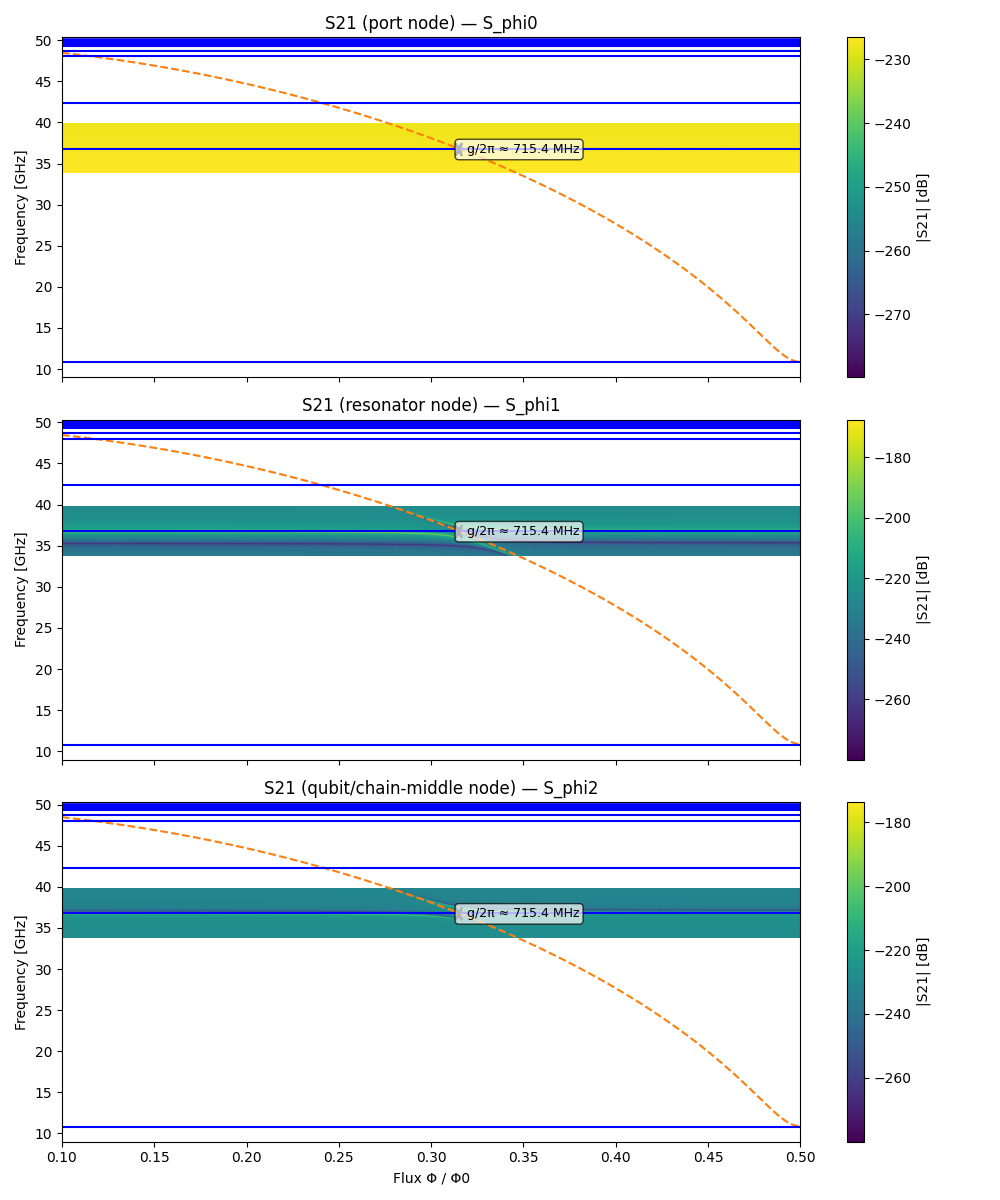

In [175]:
###############################################################################
# 4) Plot S21 colormaps and show g as an arrow (using S21_dB2)
###############################################################################

# Convert S21 to dB
eps = 1e-14  # to avoid log10(0)
S21_dB0 = 20 * np.log10(np.abs(S_phi0) + eps)
S21_dB1 = 20 * np.log10(np.abs(S_phi1) + eps)
S21_dB2 = 20 * np.log10(np.abs(S_phi2) + eps)

extent = [
    Phi_list[0]/Phi0, Phi_list[-1]/Phi0,
    f_span[0]/1e9,    f_span[-1]/1e9
]

# Frequencies in GHz for the arrow
f_minus_GHz = f_minus / 1e9
f_plus_GHz  = f_plus  / 1e9
Phi_cross_x = Phi_cross_over_Phi0

fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

titles = [
    "S21 (port node) — S_phi0",
    "S21 (resonator node) — S_phi1",
    "S21 (qubit/chain-middle node) — S_phi2"
]
S_list = [S21_dB0, S21_dB1, S21_dB2]

for ax, SdB, title in zip(axes, S_list, titles):
    im = ax.imshow(
        SdB.T,
        origin='lower',
        aspect='auto',
        extent=extent,
        cmap='viridis'
    )
    ax.set_ylabel("Frequency [GHz]")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label="|S21| [dB]")

    # Draw arrow for the splitting in this colormap
    ax.annotate(
        "",
        xy=(Phi_cross_x, f_plus_GHz),
        xytext=(Phi_cross_x, f_minus_GHz),
        arrowprops=dict(arrowstyle="<->", linewidth=2)
    )

    # Mark mid-point and label g
    f_mid_GHz = 0.5 * (f_plus_GHz + f_minus_GHz)
    ax.plot([Phi_cross_x], [f_mid_GHz], marker="o", markersize=5)

    # plt.plot(Phi_list/Phi0, f_q_list*1e-9, label='simple SQUID')
    ax.plot(Phi_list/Phi0, f_q_list_scq*1e-9, linestyle='--', label='scqubits')
    for f in freq_squid:
        ax.axhline(f*1e-9, color='blue', alpha=1)

    ax.text(
        Phi_cross_x,
        f_mid_GHz,
        f"  g/2π ≈ {g_over_2pi_MHz:.1f} MHz",
        va="center",
        ha="left",
        fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)
    )

axes[-1].set_xlabel("Flux Φ / Φ0")
plt.tight_layout()
plt.show()
# plt.close()


In [176]:
print(FREQ1, FREQ2, KAPPA, T1_PURCELL, TPHI_CHARGE,G_COUPLING)

36.78964337452675 42.33224736682204 2.913496440303482 41.81671118501607 287123767.79846656 715.4308617234497


In [177]:
# Cc_array[0]*1e15

In [178]:
import numpy as np
import datetime

# ----------------------------------------------------------
# Data to save
# ----------------------------------------------------------
# S_phi0, S_phi1, S_phi2  → your S21 arrays
# f_span, flux_span      → frequency & flux axes
# Cc                     → coupling capacitor

# ----------------------------------------------------------
# Generate unique suffix with timestamp + Cc value (fF)
# ----------------------------------------------------------
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
Cc_fF = Cc_array[0] * 1e15        # convert to fF for human-readable naming
suffix = f"_{timestamp}_Cc{Cc_fF:.3f}fF"

# ----------------------------------------------------------
# Save all arrays
# ----------------------------------------------------------
cache_folder = "simulation_cache"

np.save(f"{cache_folder}/S_phi0{suffix}.npy", S_phi0)
np.save(f"{cache_folder}/S_phi1{suffix}.npy", S_phi1)
np.save(f"{cache_folder}/S_phi2{suffix}.npy", S_phi2)

np.save(f"{cache_folder}/f_span{suffix}.npy", f_span)
np.save(f"{cache_folder}/Phi_list{suffix}.npy", Phi_list)
print("Saved with suffix:", suffix)


Saved with suffix: _20260602_113919_Cc0.272fF


In [179]:
import numpy as np

# ----------------------------------------------------------
# Insert the suffix printed when saving
# Example:
# suffix = "_20251202_193044_Cc1.5fF"
# ----------------------------------------------------------
suffix = "_20260213_161540_Cc0.018fF"  # <-- UPDATE THIS
cache_folder = "simulation_cache"
# ----------------------------------------------------------
# Load all arrays
# ----------------------------------------------------------
S_phi0 = np.load(f"{cache_folder}/S_phi0{suffix}.npy")
S_phi1 = np.load(f"{cache_folder}/S_phi1{suffix}.npy")
S_phi2 = np.load(f"{cache_folder}/S_phi2{suffix}.npy")

f_span = np.load(f"{cache_folder}/f_span{suffix}.npy")
Phi_list = np.load(f"{cache_folder}/Phi_list{suffix}.npy")

print("Loaded datasets for suffix:", suffix)


Loaded datasets for suffix: _20260213_161540_Cc0.018fF


In [180]:
'''
TODO

DONE - Cg varies 
DONE - check Cc

DONE - Plot eigenvectors to see mode shapes

DONE - How much the plasmon mode is dressed by the capacitances

DONE - MOST IMPORTANT: what is my kappa? Shall ideally be 10 MHz -> kappa is the 2nd optimization parameter to counter Purcell

first chain mode 21-23 GHz

qubit - 5-7 GHz -> what is the coupling? g ~ 500 MHz? What is kappa?
maybe increase the qubit freq to 7?

Then add losses:
loss in chain junctions - R parallel to LJ (loss tangent incerted in G matrix)
loss in Cg - tangent in G matrix


mode positioning: consider with respect to the mode math and the 1-phot/ 2 -photon transitions of the qubit -> another optimization parameter

'''

'\nTODO\n\nDONE - Cg varies \nDONE - check Cc\n\nDONE - Plot eigenvectors to see mode shapes\n\nDONE - How much the plasmon mode is dressed by the capacitances\n\nDONE - MOST IMPORTANT: what is my kappa? Shall ideally be 10 MHz -> kappa is the 2nd optimization parameter to counter Purcell\n\nfirst chain mode 21-23 GHz\n\nqubit - 5-7 GHz -> what is the coupling? g ~ 500 MHz? What is kappa?\nmaybe increase the qubit freq to 7?\n\nThen add losses:\nloss in chain junctions - R parallel to LJ (loss tangent incerted in G matrix)\nloss in Cg - tangent in G matrix\n\n\nmode positioning: consider with respect to the mode math and the 1-phot/ 2 -photon transitions of the qubit -> another optimization parameter\n\n'

1. microstrip : 50 Ohm at the ~21 GHz (1st resonator freq) (18-25 GHz window), try 40 GHz plasma freq
2. Sample box design 
3. Charge sensitivity at the half-flux Q (calc EJ/EC)
4. What is the hamiltonian? Check that paper

GOALS:
1. Directly probe the dielectric loss - with SQUID, probe T1
2. Compare Q and kappa against the non-linear bow-tie resonators (lumped Cc vs distributed Cc) - no SQUID
3. Check if impedance mismatch indeed protects the mode - with SQUID, probe T1
4. FUTURE: placing a qubit next to it to couple via the chain modes? Coupling two qubits?

NOTES:
1. The nonsymmetric large lid is extremely important for Purcell
2. Where are we putting SQUID in the end or in the middle? - plot g vs N_SQUID
3. Make SQUID are to be that of fluxonium 300 um2
4. Consider SQUID thinckness + the area features
5. Do we need to move the chain away from the 1st Lid? Add a bridge of the chainW
6. Make chainW smaller (1um)
7. Tphi - 1/f flux noise
8. Add notch filter lambda/4

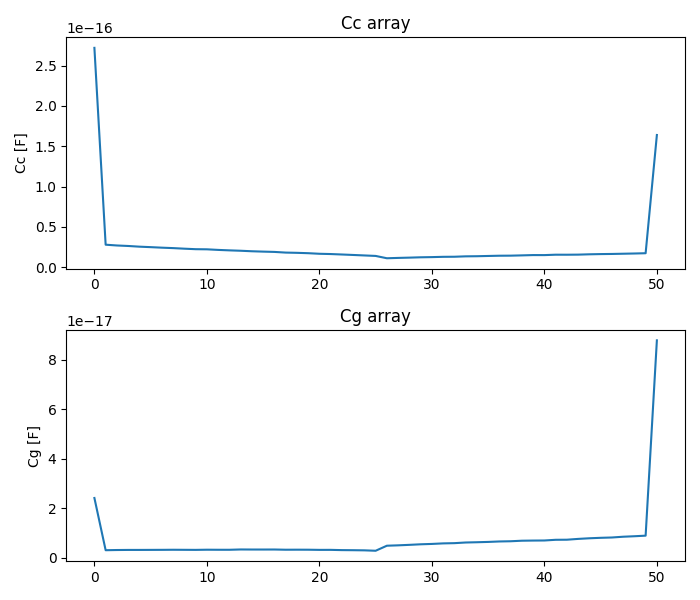

In [181]:
plt.figure(figsize=(7,6))
plt.subplot(2,1,1)
plt.plot(np.arange(len(Cc_array)), Cc_array)
plt.title("Cc array")
plt.ylabel("Cc [F]")
plt.subplot(2,1,2)
plt.plot(np.arange(len(Cg_array)), Cg_array)
plt.title("Cg array")
plt.ylabel("Cg [F]")
plt.tight_layout()
plt.show()

In [182]:
# path = r"C:\Users\gusarov\Desktop\Plasmon_Lumped_chain+trans_CapCalc_Lumped chain+trans_spacingCoupling1um_chainW2.8um_extCouplingW20um_extCouplingL11um_pitW1um_pitL1um_fstLidW10um_fstLidL10um_lastLidW10um_lastLidL10um.csv"

# # N=50
# # path = r"C:\Users\gusarov\Desktop\Plasmon_Lumped_chain+trans_CapCalc_Lumped chain+trans_spacingCoupling1um_chainW2.8um_extCouplingW20um_extCouplingL11um_pitW1um_pitL1um_fstLidW10um_fstLidL10um_lastLidW10um_lastLidL10um_N50.csv"

# Cg_fF, Cc_fF, info = extract_Cg_Cc_simple(path, debug=True)
# Cg_array = np.array(Cg_fF) * fF_to_F
# Cc_array = np.array(Cc_fF) * fF_to_F

# Cc_array_from_N100 = Cc_array[::2]  # Take every other element to match the islands (assuming interleaved)
# Cg_array_from_N100 = Cg_array[::2]  # Take every other element to match the islands (assuming interleaved)

In [183]:
# path = r"C:\Users\gusarov\Desktop\Plasmon_Lumped_chain+trans_CapCalc_Lumped chain+trans_spacingCoupling1um_chainW2.8um_extCouplingW20um_extCouplingL11um_pitW1um_pitL1um_fstLidW10um_fstLidL10um_lastLidW10um_lastLidL10um_N50.csv"

# Cg_fF, Cc_fF, info = extract_Cg_Cc_simple(path, debug=True)
# Cg_array_from_N50 = np.array(Cg_fF) * fF_to_F
# Cc_array_from_N50 = np.array(Cc_fF) * fF_to_F

In [184]:
# Cc_array_from_N50.shape, Cc_array_from_N100.shape

In [185]:
# plt.figure(figsize=(7,6))
# plt.subplot(2,1,1)
# plt.plot(np.arange(len(Cc_array_from_N50)), Cc_array_from_N50, label='N=50')
# plt.plot(np.arange(len(Cc_array_from_N100)), Cc_array_from_N100, label='N=100')
# plt.title("Cc array")
# plt.ylabel("Cc [F]")
# plt.legend()
# plt.subplot(2,1,2)
# plt.plot(np.arange(len(Cg_array_from_N50)), Cg_array_from_N50, label='N=50')
# plt.plot(np.arange(len(Cg_array_from_N100)), Cg_array_from_N100, label='N=100')
# plt.title("Cg array")
# plt.ylabel("Cg [F]")
# plt.legend()
# plt.tight_layout()
# plt.show()

In [186]:
# Cg_array_from_N50[-1], Cc_array_from_N50[-1], Cg_array_from_N100[-1], Cc_array_from_N100[-1]